# Myeloid populations in Xenium EAE: metabolic identity, ketone handling, position and disease course

The EAE object annotates ten myeloid populations (homeostatic microglia, "Activate Mic_Mac 1", "Activated Mic_Mac 2", foamy and efflux
microglia / macrophages, macrophages, infiltrating "Myeloid cells", proliferating microglia, dendritic cells, APCs) plus a microglia–astrocyte
doublet-like cluster ("Mic_AST"). The other notebooks treat them as one block; here each population gets its own metabolic profile.

Questions:

1. **Composition.** How are the populations distributed over condition, model, disease course and lesion distance?
2. **Metabolic identity.** Pathway scores (glycolysis, lactate, TCA, β-oxidation, lipid synthesis, cholesterol synthesis, lipid storage) and the
   focus genes per population; which are glycolytic, which are lipid-laden, which oxidise fatty acids.
3. **Ketone handling.** *Bdh1*, MCT1 / MCT4, *Hcar2*, *Ffar2* / *Ffar3*, *Nlrp3*, the β-oxidation chain and *Ppara* per population; *Hcar2* / *Nlrp3*
   co-detection.
4. **Each population versus homeostatic microglia**, paired within EAE samples.
5. **The *Hcar2*⁺ phenotype.** Inside each population, which panel genes distinguish *Hcar2*⁺ from *Hcar2*⁻ cells?
6. **Lesion distance** per population for the key genes and scores.
7. **Disease course**: composition and *Hcar2* / lipid genes over onset, peak, remission and chronic stages.
8. **Spatial**: which myeloid populations surround DA versus homeostatic oligodendrocytes, and are *Hcar2*⁺ cells of each population enriched there?
9. Maps and interpretation.

All comparisons are pseudobulk per sample (≥20 cells per sample × population) with Mann–Whitney across samples or paired Wilcoxon within samples.

In [1]:
import os, sys, gc, re, warnings
warnings.filterwarnings("ignore")
sys.path.insert(0, "../../scripts")
try:
    from dotenv import load_dotenv
    load_dotenv("../../.env")
except Exception:
    pass
import numpy as np, pandas as pd, scipy.sparse as sp, h5py, scanpy as sc, seaborn as sns, matplotlib.pyplot as plt
from scipy import stats
import oligometab as om
from oligometab import ALL_GENES, SCORE_SETS, EAE5K_KETONE_GENES, heat

sc.settings.verbosity = 0
sc.set_figure_params(dpi=80, frameon=False)
pd.set_option("display.width", 220); pd.set_option("display.max_columns", 60); pd.set_option("display.max_rows", 300)

PATH = om.resolve_path("OLIGOMETAB_XENIUM_EAE_H5AD", "../../data/RREAE_5k_raw_only_integration_processed.h5ad")
MYELOID = ["Microglia", "Activate Mic_Mac 1", "Activated Mic_Mac 2", "Foamy Mic_Mac", "Efflux Mic_Mac", "Macrophages", "Myeloid cells", "Proliferating microglia", "Dendritic cells", "APCs", "Mic_AST"]
KETONE = EAE5K_KETONE_GENES
FOCUS_MY = ["Hk2", "Pfkp", "Pkm", "Ldha", "Slc2a1", "Slc16a3", "Slc16a1", "Pdk1", "Cs", "Sdha", "Cpt1a", "Cpt2", "Hadhb", "Acaa2", "Plin2", "Plin4", "Cd36", "Lpl", "Abca1", "Nr1h3", "Fasn", "Srebf1", "Hmgcr", "Hif1a", "Txnip", "Ppara", "Pparg", "Bdh1", "Hcar2", "Nlrp3", "Acss1", "Acss2"]
MARKERS = ["P2ry12", "Tmem119", "Cx3cr1", "Hexb", "Csf1r", "Cd68", "Itgam", "Lyz2", "Ccr2", "Ly6c2", "Spp1", "Gpnmb", "Trem2", "Tyrobp", "Lgals3", "Igf1", "Apoc1", "Fabp5", "Lipa", "Npc2", "Ctsd", "Cst7", "Clec7a", "Il1b", "Tnf", "Ccl2", "Cd74", "H2-Ab1", "Mki67", "Top2a", "Abcg1", "Msr1", "Mertk", "Axl", "C1qa", "C3", "C4b", "Serpina3n"]
os.makedirs("../../results", exist_ok=True)
R = {}


def save(name, df):
    R[name] = df; df.to_csv(f"../../results/eae_myeloid_{name}.csv")


def bin_order(values):
    return sorted([v for v in values if str(v) not in ("nan", "None")], key=lambda b: (1, 0) if str(b).startswith(">") else (0, int(re.search(r"(\d+)", str(b)).group(1))))


def paired_vs_reference(adata, genes, sample_col, pop_col, pops, ref, min_cells=20, values=None):
    """Each population vs the reference population within the same sample: log2FC of mean of per-sample means (or difference for scores), paired Wilcoxon."""
    df = om.expr_df(adata, genes) if values is None else values
    smp = adata.obs[sample_col].astype(str).values; pop = adata.obs[pop_col].astype(str).values
    rows = []
    for p in pops:
        A, B = [], []
        for s_ in np.unique(smp):
            m = smp == s_
            if (m & (pop == p)).sum() >= min_cells and (m & (pop == ref)).sum() >= min_cells:
                A.append(df[m & (pop == p)].mean()); B.append(df[m & (pop == ref)].mean())
        A, B = pd.DataFrame(A), pd.DataFrame(B)
        for g in df.columns:
            if not len(A):
                continue
            eff = om.log2fc(A[g].mean(), B[g].mean()) if values is None else A[g].mean() - B[g].mean()
            rows.append({"population": p, "feature": g, "effect": eff, "n_samples": len(A), "frac_samples_up": float((A[g] > B[g]).mean()),
                         "wilcoxon_p": stats.wilcoxon(A[g], B[g]).pvalue if len(A) >= 3 and not np.allclose(A[g], B[g]) else np.nan})
    return pd.DataFrame(rows)


def star_heat(df, title, cbar, index, columns, value, pvalue, vmin, vmax, fmt=".1f"):
    d = df.pivot(index=index, columns=columns, values=value); p = df.pivot(index=index, columns=columns, values=pvalue).reindex(index=d.index, columns=d.columns)
    heat(d, title, cbar, fmt=fmt, cmap="RdBu_r", center=0, vmin=vmin, vmax=vmax, annot=(d.round(1 if fmt == ".1f" else 2).astype(str).replace("nan", "") + np.where(p.values < 0.05, "*", "")).values, row_labels=list(d.index))
    return d

In [2]:
from anndata import AnnData
from anndata.experimental import read_elem
with h5py.File(PATH, "r") as f:
    obs = read_elem(f["obs"]); var = read_elem(f["var"])
    shape = tuple(f["X"].attrs["shape"])
    X = sp.csr_matrix((f["X/data"][:].astype(np.float32), f["X/indices"][:], f["X/indptr"][:]), shape=shape)
    spatial = f["obsm/spatial"][:]
obs.index = obs.index.astype(str); var.index = var.index.astype(str)
ad = AnnData(X=X, obs=obs, var=var); ad.obsm["spatial"] = spatial; ad.obs_names_make_unique(); del X, obs, var
ad.obs["cell_type"] = ad.obs["cell_type"].astype(str).replace({"DA oligodendrocytes": "DA Oligodendrocytes", "Astrocyte": "Astrocytes"})
sc.pp.normalize_total(ad, target_sum=1e4); sc.pp.log1p(ad)
P = om.pathway_scores(ad, SCORE_SETS, min_genes=3)
for c in P.columns:
    ad.obs["score::" + c] = P[c].values
ad.obs["FA_supply_score"] = om.pathway_scores(ad, {"FA supply": ["Cpt1a", "Cpt2", "Slc25a20", "Hadhb", "Hadh", "Echs1", "Acaa2"]}, min_genes=3)["FA supply"].values
meta = ad.obs.groupby("sample_name", observed=True).agg(condition=("condition", "first"), model=("model", "first"), course=("course", "first"), n_cells=("condition", "size"))
meta["frac_lesion"] = ad.obs.groupby("sample_name", observed=True)["lesion_density_call"].apply(lambda s: (s.astype(str) != "non_lesion").mean())
bins = bin_order(ad.obs["lesion_distance_bin"].astype(str).unique())
my = ad[ad.obs["cell_type"].isin(MYELOID)].copy()
my.obs["population"] = pd.Categorical(my.obs["cell_type"].astype(str), categories=MYELOID)
markers = om.present(my, MARKERS); ketone = om.present(my, KETONE); focus = om.present(my, FOCUS_MY); metab = om.present(my, ALL_GENES)
print(my.shape, "| markers on panel:", markers); print("ketone genes:", ketone)
print(my.obs["population"].value_counts())

(206016, 5101) | markers on panel: ['P2ry12', 'Tmem119', 'Cx3cr1', 'Hexb', 'Csf1r', 'Cd68', 'Itgam', 'Ccr2', 'Gpnmb', 'Trem2', 'Igf1', 'Cst7', 'Tnf', 'Ccl2', 'Cd74', 'H2-Ab1', 'Mki67', 'Top2a', 'Msr1', 'Mertk', 'Axl', 'C3', 'C4b', 'Serpina3n']
ketone genes: ['Bdh1', 'Slc16a1', 'Slc16a3', 'Slc5a12', 'Hcar2', 'Ffar3', 'Ffar2', 'Nlrp3', 'Cpt1a', 'Cpt1c', 'Cpt2', 'Slc25a20', 'Hadhb', 'Hadh', 'Echs1', 'Acaa2', 'Ppara', 'Ppargc1a', 'Pdk4', 'Fgf21', 'Klb', 'Acss1', 'Acss2']
population
Microglia                  56065
Macrophages                32806
Activated Mic_Mac 2        24097
Activate Mic_Mac 1         18077
Efflux Mic_Mac             17895
Foamy Mic_Mac              12961
APCs                       12516
Myeloid cells              10389
Mic_AST                     8134
Proliferating microglia     7082
Dendritic cells             5994
Name: count, dtype: int64


## 1. Composition: where and when are the populations?

cells per population, EAE vs CONTROL (counts and column fractions):


condition,CONTROL,EAE,CONTROL_frac,EAE_frac
population,,,,
Microglia,2107,53958,0.599,0.266
Activate Mic_Mac 1,923,17154,0.263,0.085
Activated Mic_Mac 2,38,24059,0.011,0.119
Foamy Mic_Mac,1,12960,0.000,0.064
Efflux Mic_Mac,154,17741,0.044,0.088
Macrophages,19,32787,0.005,0.162
Myeloid cells,77,10312,0.022,0.051
Proliferating microglia,19,7063,0.005,0.035
Dendritic cells,3,5991,0.001,0.030


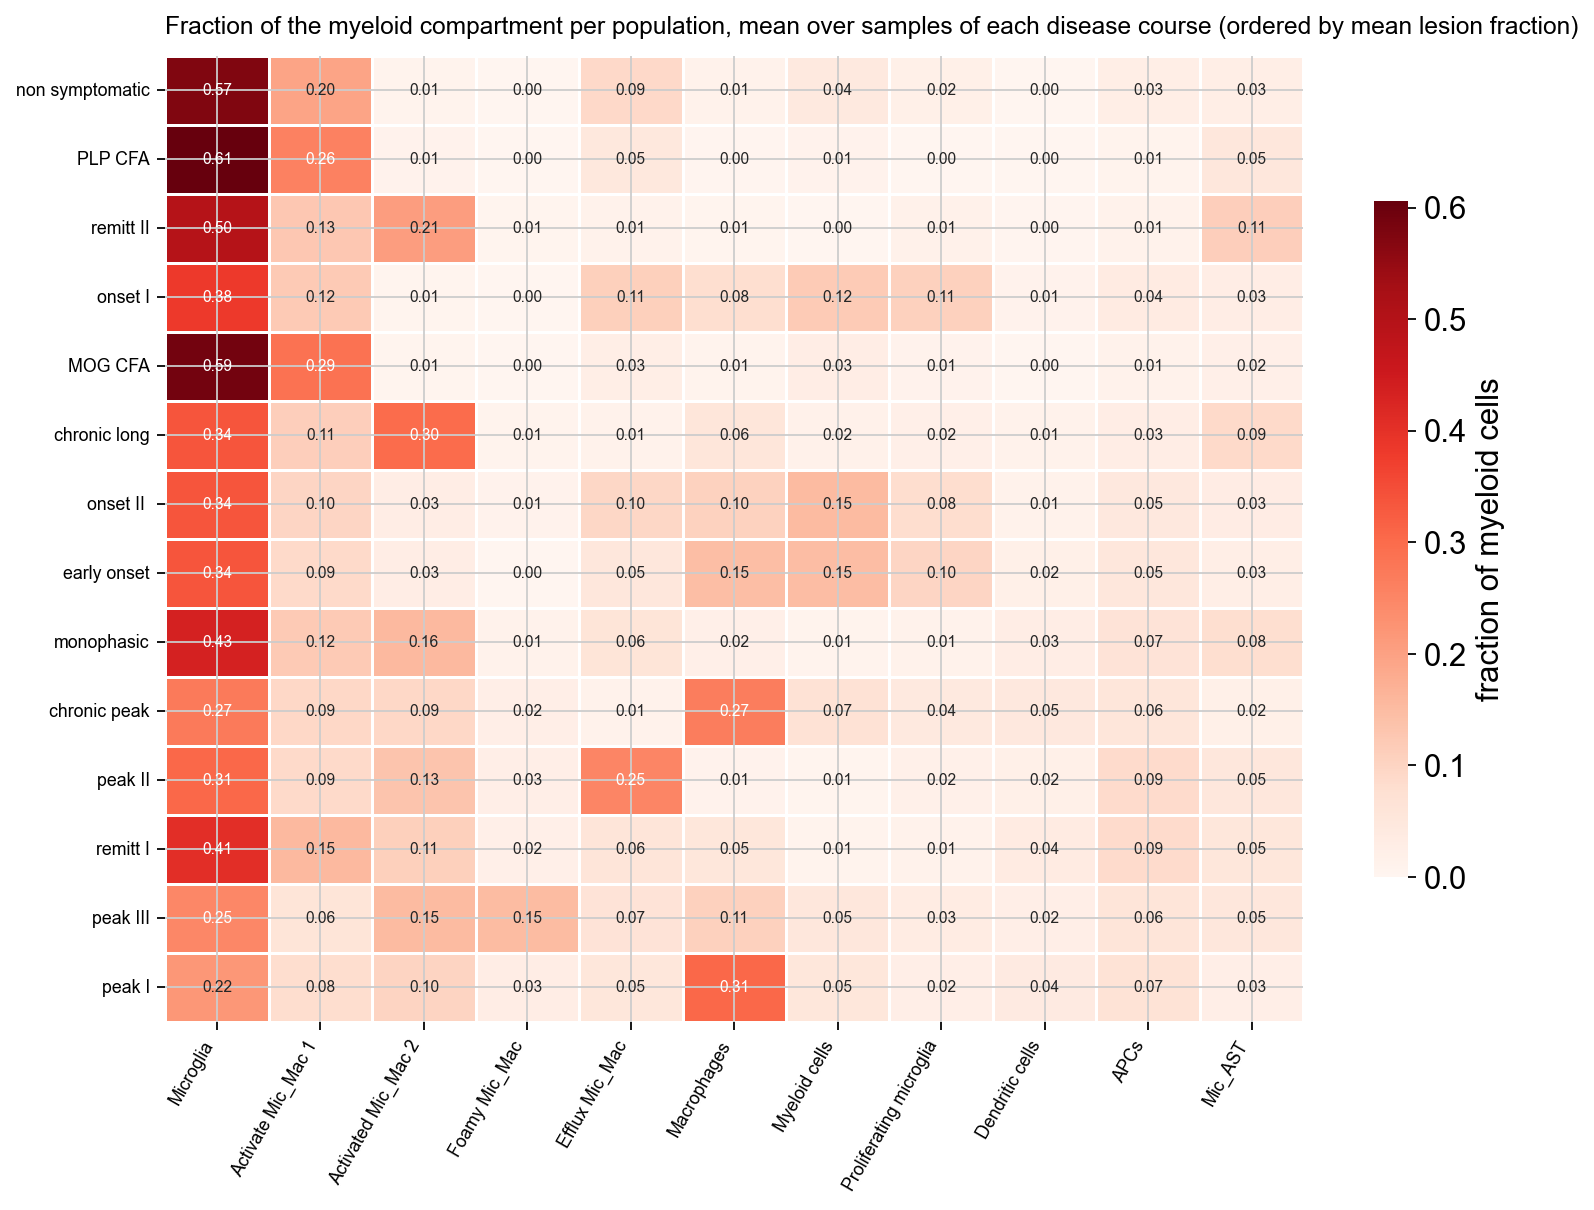

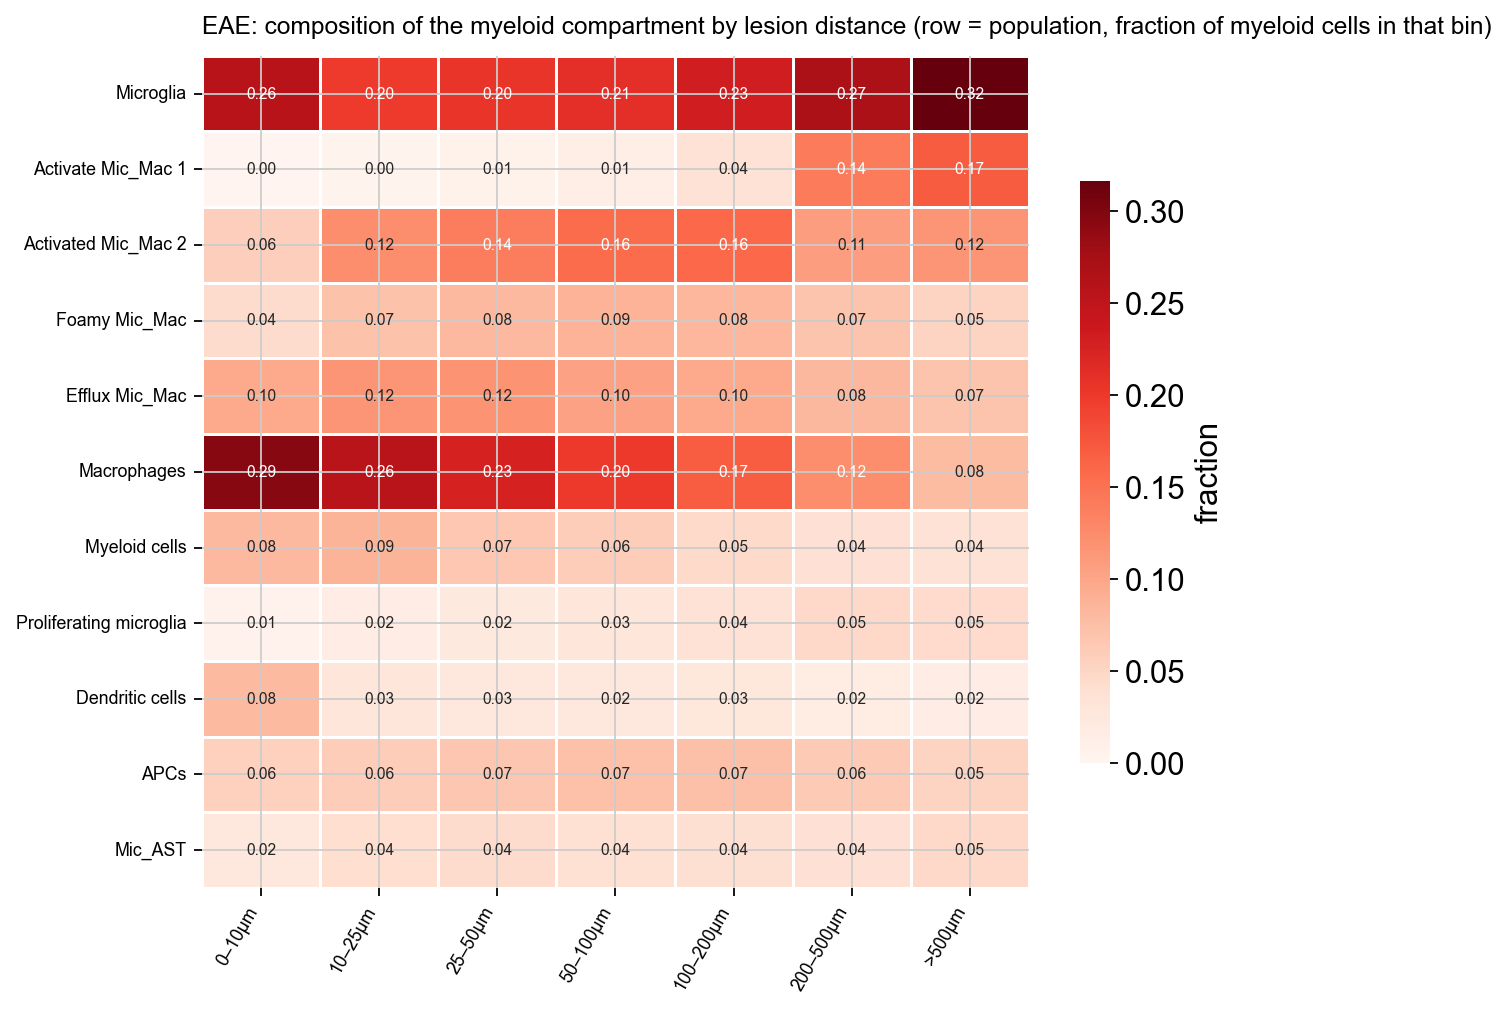

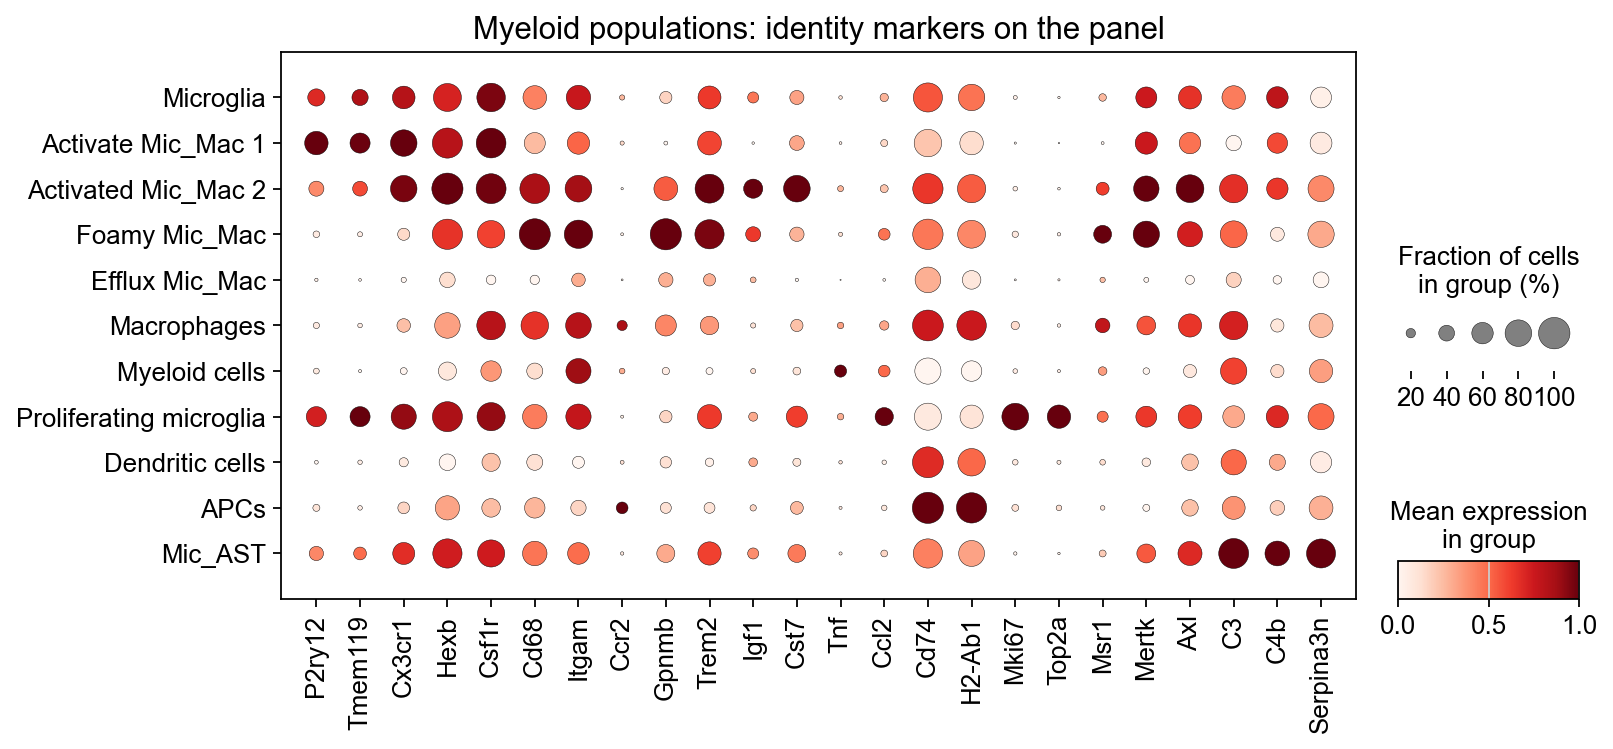

,spearman_rho_vs_lesion_fraction,p,mean_frac_EAE,mean_frac_CONTROL
population,,,,
Microglia,-0.392,0.000,0.351,0.600
Activate Mic_Mac 1,-0.322,0.002,0.109,0.271
Activated Mic_Mac 2,0.094,0.370,0.118,0.009
Foamy Mic_Mac,0.578,0.000,0.027,0.000
Efflux Mic_Mac,0.251,0.016,0.074,0.039
Macrophages,0.447,0.000,0.102,0.005
Myeloid cells,0.018,0.866,0.053,0.019
Proliferating microglia,-0.186,0.076,0.038,0.006
Dendritic cells,0.687,0.000,0.023,0.001


In [3]:
comp = pd.crosstab(my.obs["population"], my.obs["condition"].astype(str)); comp_frac = comp.div(comp.sum(0), axis=1); save("composition_by_condition", comp.join(comp_frac, rsuffix="_frac"))
print("cells per population, EAE vs CONTROL (counts and column fractions):"); display(comp.join(comp_frac.round(3), rsuffix="_frac"))
# per sample fraction of the myeloid compartment, by course
per_sample = pd.crosstab(my.obs["sample_name"].astype(str), my.obs["population"]); per_sample = per_sample.div(per_sample.sum(1), axis=0)
per_sample = per_sample.join(meta[["condition", "model", "course", "frac_lesion"]])
order_c = list(meta.groupby("course", observed=True)["frac_lesion"].mean().sort_values().index)
course_comp = per_sample.groupby("course", observed=True)[MYELOID].mean().reindex(order_c); save("composition_by_course", course_comp)
heat(course_comp, "Fraction of the myeloid compartment per population, mean over samples of each disease course (ordered by mean lesion fraction)", "fraction of myeloid cells", fmt=".2f", cmap="Reds", center=None, vmin=0, vmax=None, row_labels=list(course_comp.index))
# lesion distance
m_eae = ((my.obs["condition"] == "EAE") & my.obs["lesion_distance_bin"].notna()).values
ld_comp = pd.crosstab(my.obs.loc[m_eae, "lesion_distance_bin"].astype(str), my.obs.loc[m_eae, "population"]).reindex(bins); ld_frac = ld_comp.div(ld_comp.sum(1), axis=0); save("composition_by_lesion_distance", ld_frac)
heat(ld_frac.T, "EAE: composition of the myeloid compartment by lesion distance (row = population, fraction of myeloid cells in that bin)", "fraction", fmt=".2f", cmap="Reds", center=None, vmin=0, vmax=None, row_labels=MYELOID)
# marker sanity check
r = om.resolve(my, markers)
sc.pl.dotplot(my, var_names=[r[g] for g in markers], groupby="population", standard_scale="var", color_map="Reds", figsize=(0.35 * len(markers) + 2, 4.5), show=False, title="Myeloid populations: identity markers on the panel"); plt.show()
# per-sample correlation of population fractions with lesion burden (EAE samples)
rows = []
for p in MYELOID:
    e = per_sample[per_sample.condition == "EAE"]
    if e[p].std() > 0:
        rho, pv = stats.spearmanr(e["frac_lesion"], e[p]); rows.append({"population": p, "spearman_rho_vs_lesion_fraction": rho, "p": pv, "mean_frac_EAE": e[p].mean(), "mean_frac_CONTROL": per_sample[per_sample.condition == "CONTROL"][p].mean()})
burden = pd.DataFrame(rows).set_index("population"); save("composition_vs_lesion_burden", burden); display(burden.round(3))

## 2. Metabolic identity of each population

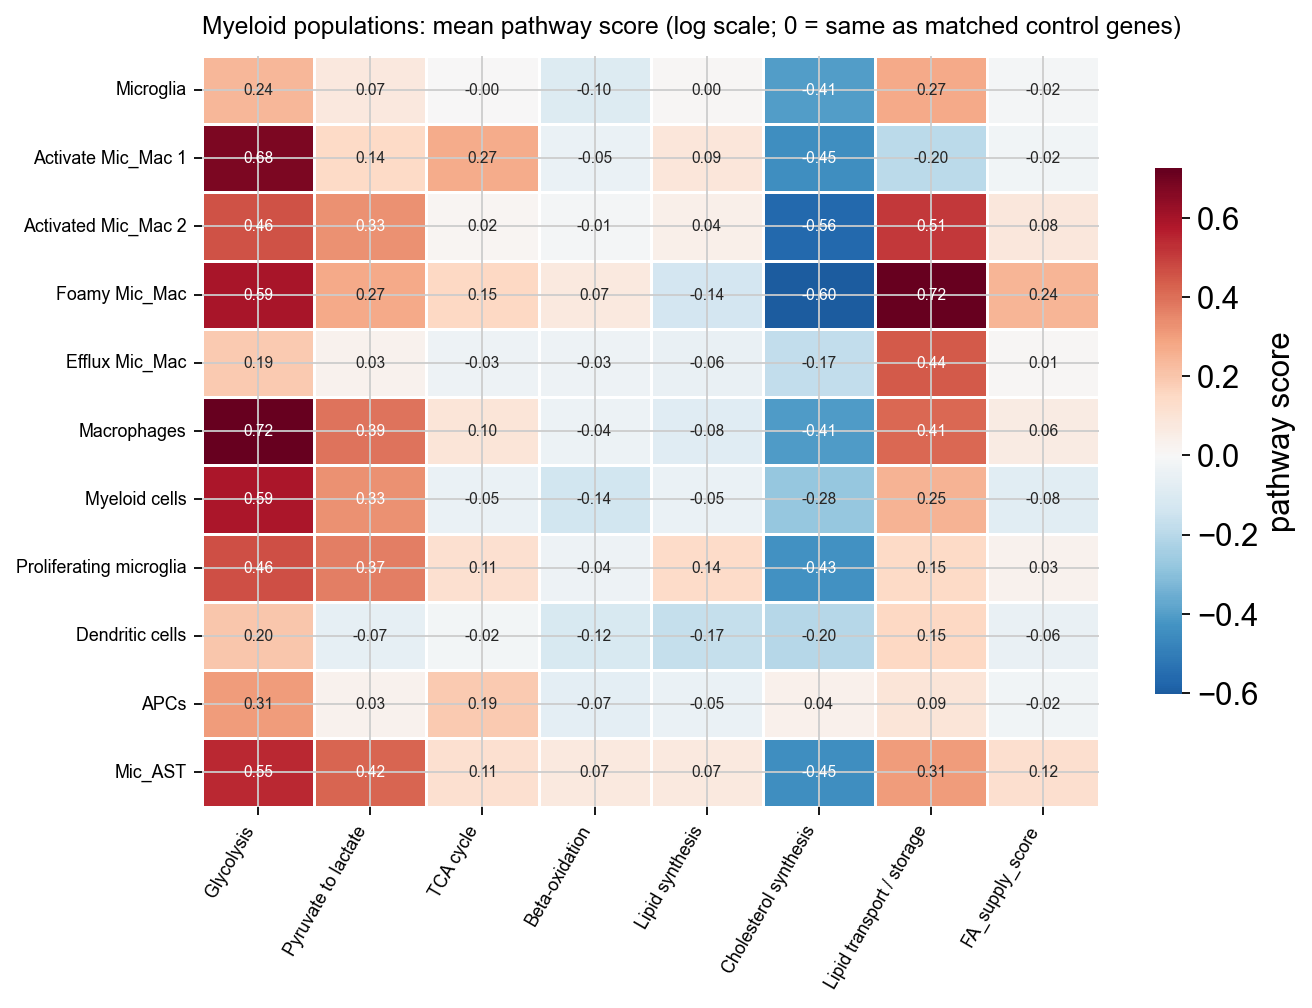

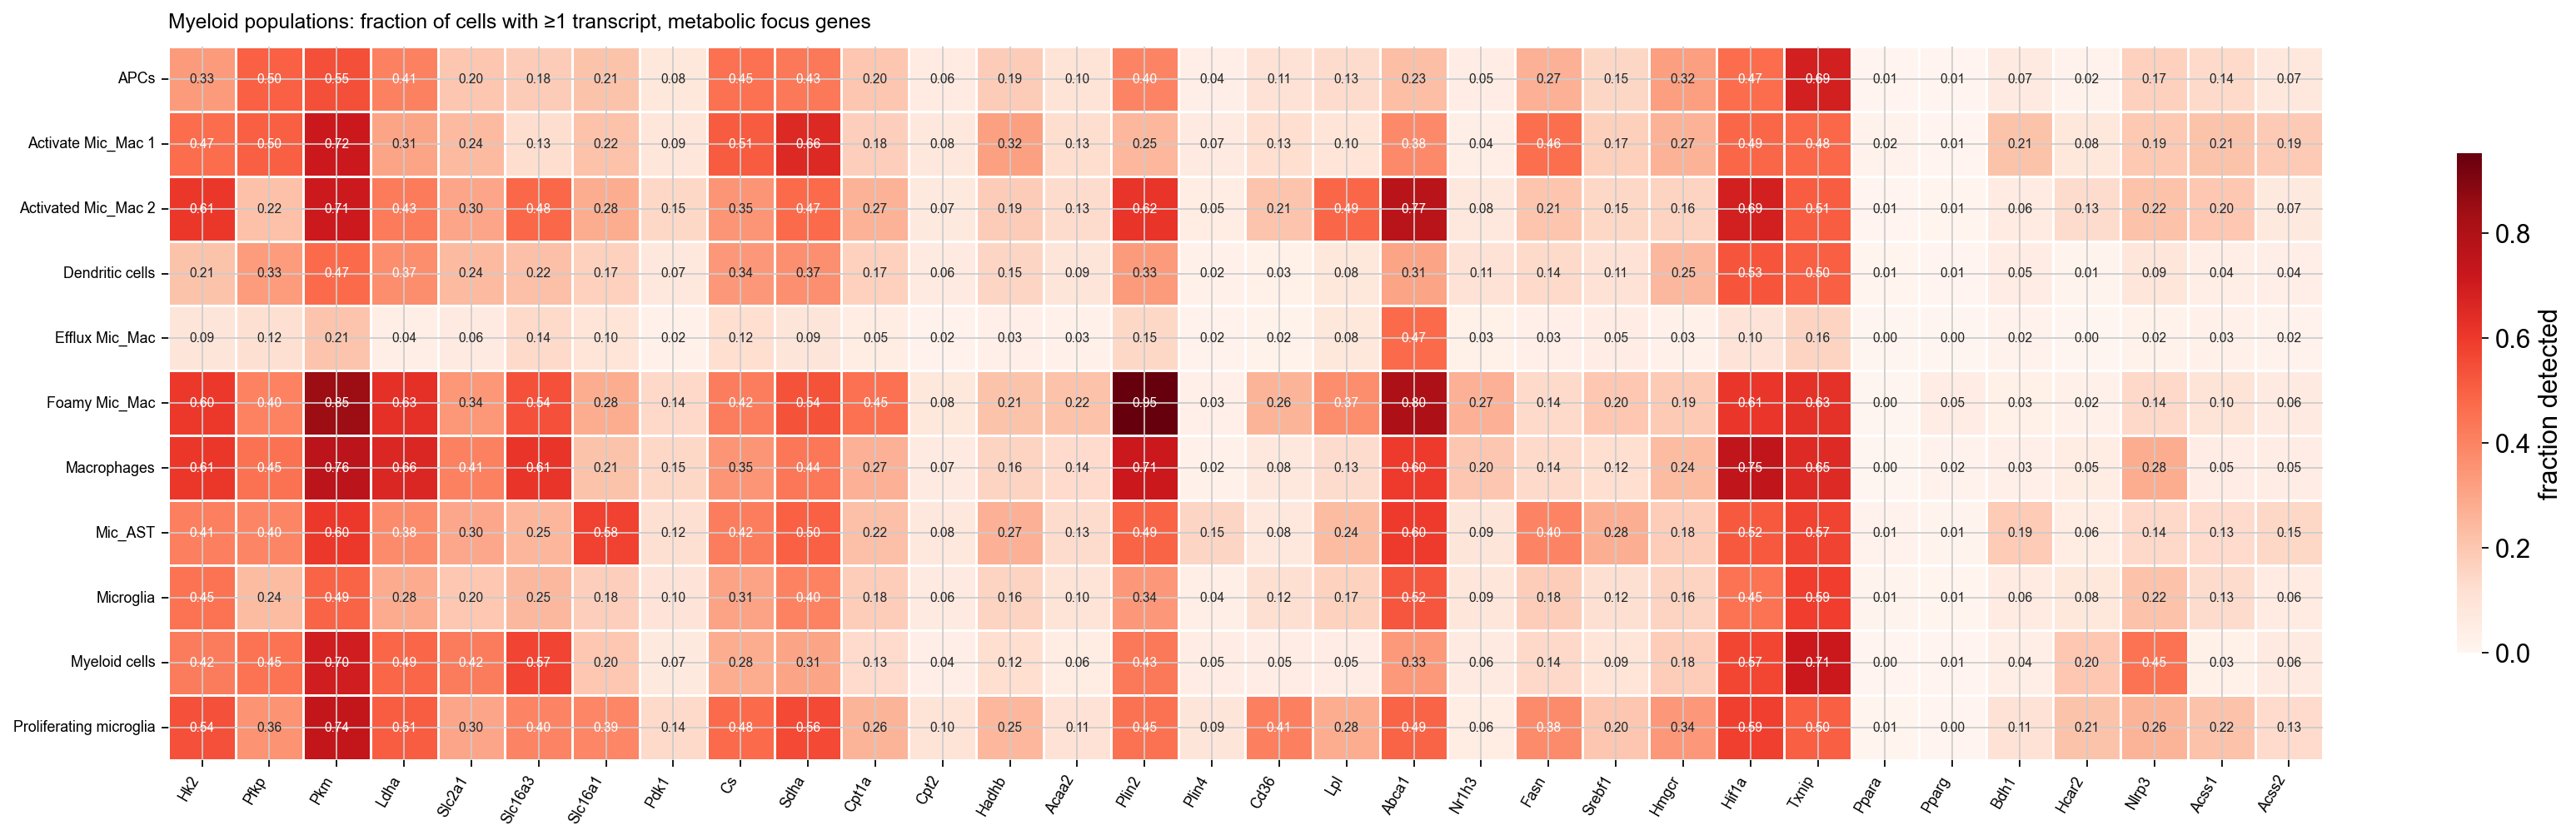

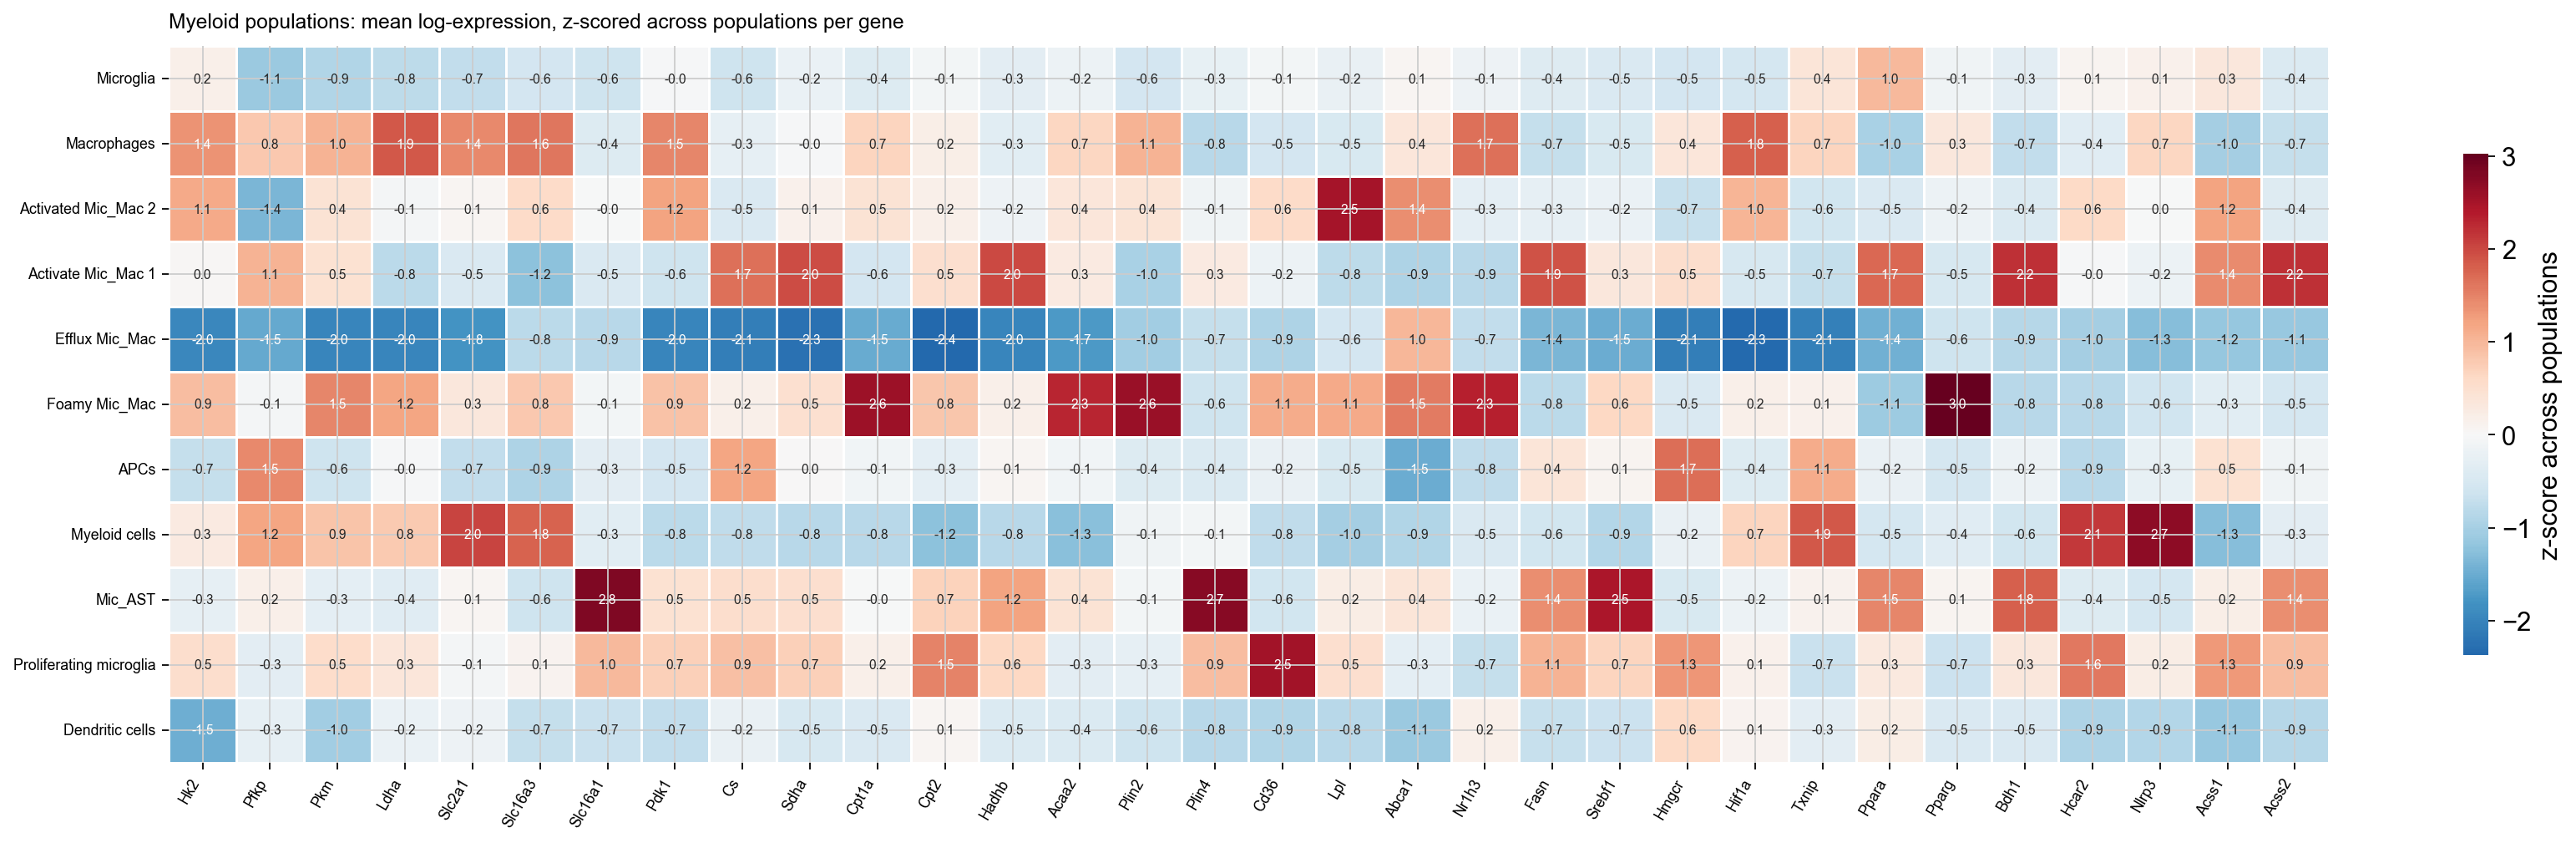

most population-specific metabolic genes (highest z across populations):
  Microglia                  Apod, Mlxipl, Ppara, Ffar3, Rptor, Ehhadh, Prkn, Txnip
  Macrophages                Acsl1, Ldha, Hif1a, Eno1, Nr1h3, Slc16a3, Pgk1, Tpi1
  Activated Mic_Mac 2        Lpl, Acaca, Abca1, Mlxipl, Nfe2l2, Echs1, Pdk1, Acss1
  Activate Mic_Mac 1         Eno2, Ppargc1a, Mpc2, Mfn2, Aldoc, Acsl6, Sirt3, Prkaa2
  Efflux Mic_Mac             Slc2a4, Abca1, Eno2, Ffar3, Prkn, Lpl, Ffar2, Ppargc1a
  Foamy Mic_Mac              Pparg, Plin2, Cpt1a, Idh1, Nr1h3, Acaa2, G6pdx, Slc25a20
  APCs                       Srebf2, Ffar2, Ddit4, Hmgcr, Fh1, Pfkp, Lss, Cs
  Myeloid cells              Hcar2, Slc2a3, Slc2a1, Ffar2, Nr1h2, Txnip, Slc16a3, Pfkp
  Mic_AST                    Slc16a1, Plin4, Fabp7, Srebf1, Pdk4, Acox1, Bdh1, Pygb
  Proliferating microglia    Cd36, Nrf1, Cpt1c, Ehhadh, Hcar2, Cpt2, Mlxipl, Acly
  Dendritic cells            Sirt1, Dnm1l, Nr1h2, Epas1, Rptor, Ldlr, Ddit4, Slc25a20


In [4]:
score_cols = [c for c in my.obs.columns if c.startswith("score::")] + ["FA_supply_score"]
S = my.obs.groupby("population", observed=True)[score_cols].mean(); S.columns = [c.replace("score::", "") for c in S.columns]; save("pathway_scores_by_population", S)
heat(S, "Myeloid populations: mean pathway score (log scale; 0 = same as matched control genes)", "pathway score", fmt=".2f", cmap="RdBu_r", center=0, row_labels=list(S.index))
det = om.detection_table(my, focus, "population", min_cells=300); save("detection_focus_by_population", det)
heat(det[focus], "Myeloid populations: fraction of cells with ≥1 transcript, metabolic focus genes", "fraction detected", fmt=".2f", cmap="Reds", center=None, vmin=0, vmax=None, row_labels=list(det.index))
mt = om.mean_table(my, focus, "population", min_cells=300); save("mean_focus_by_population", mt)
z = (mt - mt.mean()) / mt.std(ddof=0)
heat(z, "Myeloid populations: mean log-expression, z-scored across populations per gene", "z-score across populations", fmt=".1f", cmap="RdBu_r", center=0, row_labels=list(z.index))
# gene-level identity: top panel metabolic genes per population (z across populations)
mt_all = om.mean_table(my, metab, "population", min_cells=300); z_all = (mt_all - mt_all.mean()) / mt_all.std(ddof=0); save("mean_all_metabolic_by_population", mt_all)
top = {p: ", ".join(z_all.loc[p].sort_values(ascending=False).head(8).index) for p in z_all.index}
print("most population-specific metabolic genes (highest z across populations):")
for p, t in top.items():
    print(f"  {p:26s} {t}")

## 3. Ketone handling per population

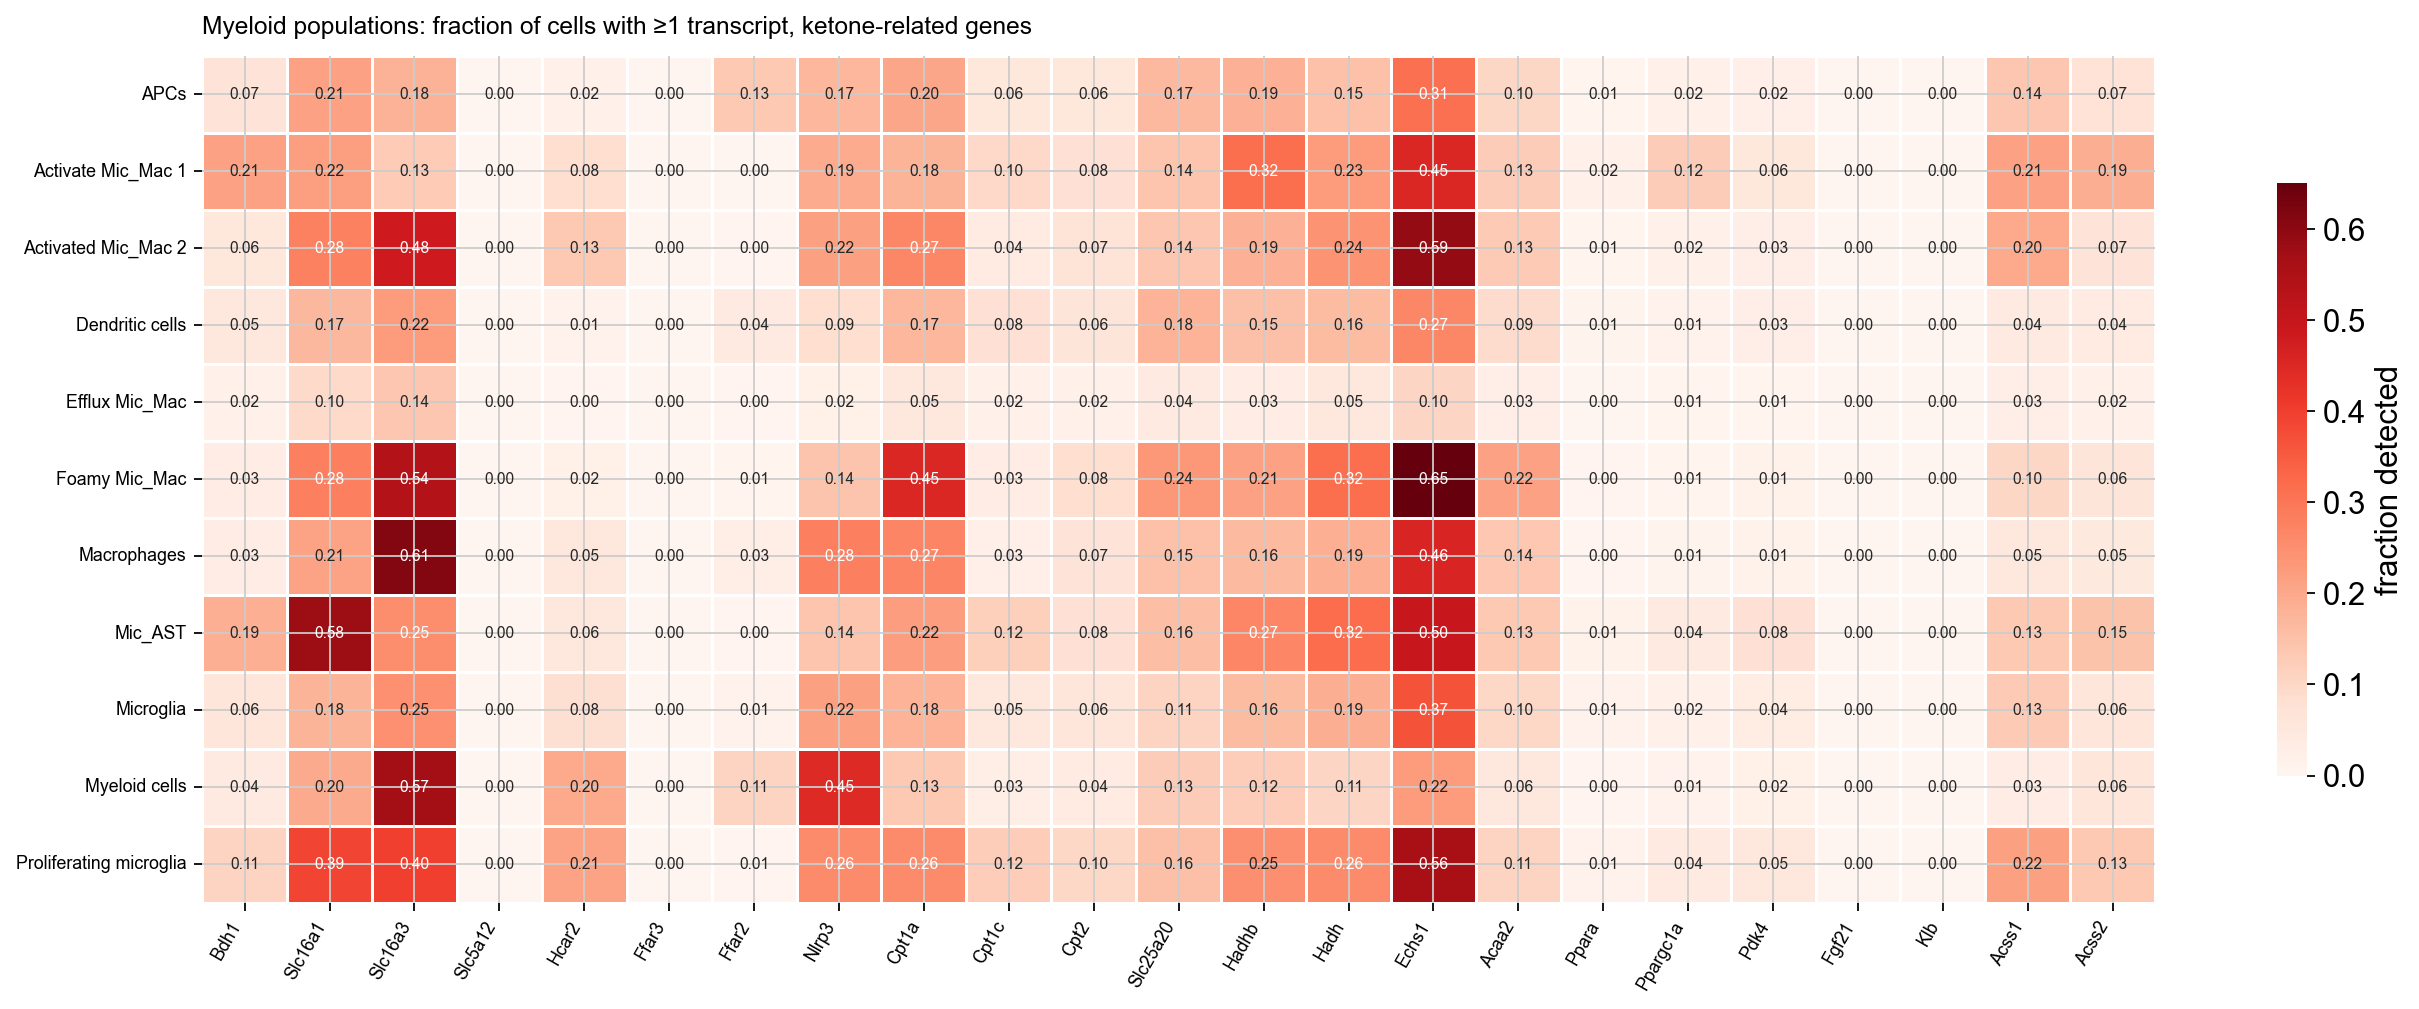

,n,Hcar2+,Nlrp3+,Hcar2+Nlrp3+,expected_if_independent,Hcar2+Cd36+,Hcar2+Plin2+,Hcar2+Slc16a3+,Bdh1+Cpt1a+
population,,,,,,,,,
Microglia,56065,0.083,0.217,0.030,0.018,0.024,0.027,0.026,0.014
Activate Mic_Mac 1,18077,0.084,0.194,0.026,0.016,0.021,0.026,0.016,0.053
Activated Mic_Mac 2,24097,0.132,0.217,0.046,0.029,0.045,0.089,0.082,0.018
Foamy Mic_Mac,12961,0.022,0.143,0.004,0.003,0.008,0.022,0.016,0.017
Efflux Mic_Mac,17895,0.003,0.021,0.000,0.000,0.000,0.001,0.001,0.002
Macrophages,32806,0.054,0.280,0.022,0.015,0.008,0.045,0.040,0.012
Myeloid cells,10389,0.199,0.446,0.114,0.089,0.018,0.120,0.137,0.010
Proliferating microglia,7082,0.212,0.259,0.086,0.055,0.128,0.103,0.108,0.040
Dendritic cells,5994,0.012,0.086,0.003,0.001,0.002,0.007,0.006,0.012


In [5]:
detk = om.detection_table(my, ketone, "population", min_cells=300); save("detection_ketone_by_population", detk)
heat(detk[ketone], "Myeloid populations: fraction of cells with ≥1 transcript, ketone-related genes", "fraction detected", fmt=".2f", cmap="Reds", center=None, vmin=0, vmax=None, row_labels=list(detk.index))
mtk = om.mean_table(my, ketone, "population", min_cells=300); save("mean_ketone_by_population", mtk)
# co-detection of the BHB sensors
df = om.expr_df(my, ["Hcar2", "Nlrp3", "Ffar2", "Slc16a3", "Cd36", "Plin2", "Lpl", "Cpt1a", "Bdh1"]); pop = my.obs["population"].astype(str).values
rows = []
for p in MYELOID:
    m = pop == p; d = df[m]
    rows.append({"population": p, "n": int(m.sum()), "Hcar2+": (d.Hcar2 > 0).mean(), "Nlrp3+": (d.Nlrp3 > 0).mean(), "Hcar2+Nlrp3+": ((d.Hcar2 > 0) & (d.Nlrp3 > 0)).mean(),
                 "expected_if_independent": (d.Hcar2 > 0).mean() * (d.Nlrp3 > 0).mean(), "Hcar2+Cd36+": ((d.Hcar2 > 0) & (d.Cd36 > 0)).mean(), "Hcar2+Plin2+": ((d.Hcar2 > 0) & (d.Plin2 > 0)).mean(),
                 "Hcar2+Slc16a3+": ((d.Hcar2 > 0) & (d.Slc16a3 > 0)).mean(), "Bdh1+Cpt1a+": ((d.Bdh1 > 0) & (d.Cpt1a > 0)).mean()})
cd = pd.DataFrame(rows).set_index("population"); save("sensor_codetection", cd); display(cd.round(3))

## 4. Each population versus homeostatic microglia, paired within EAE samples

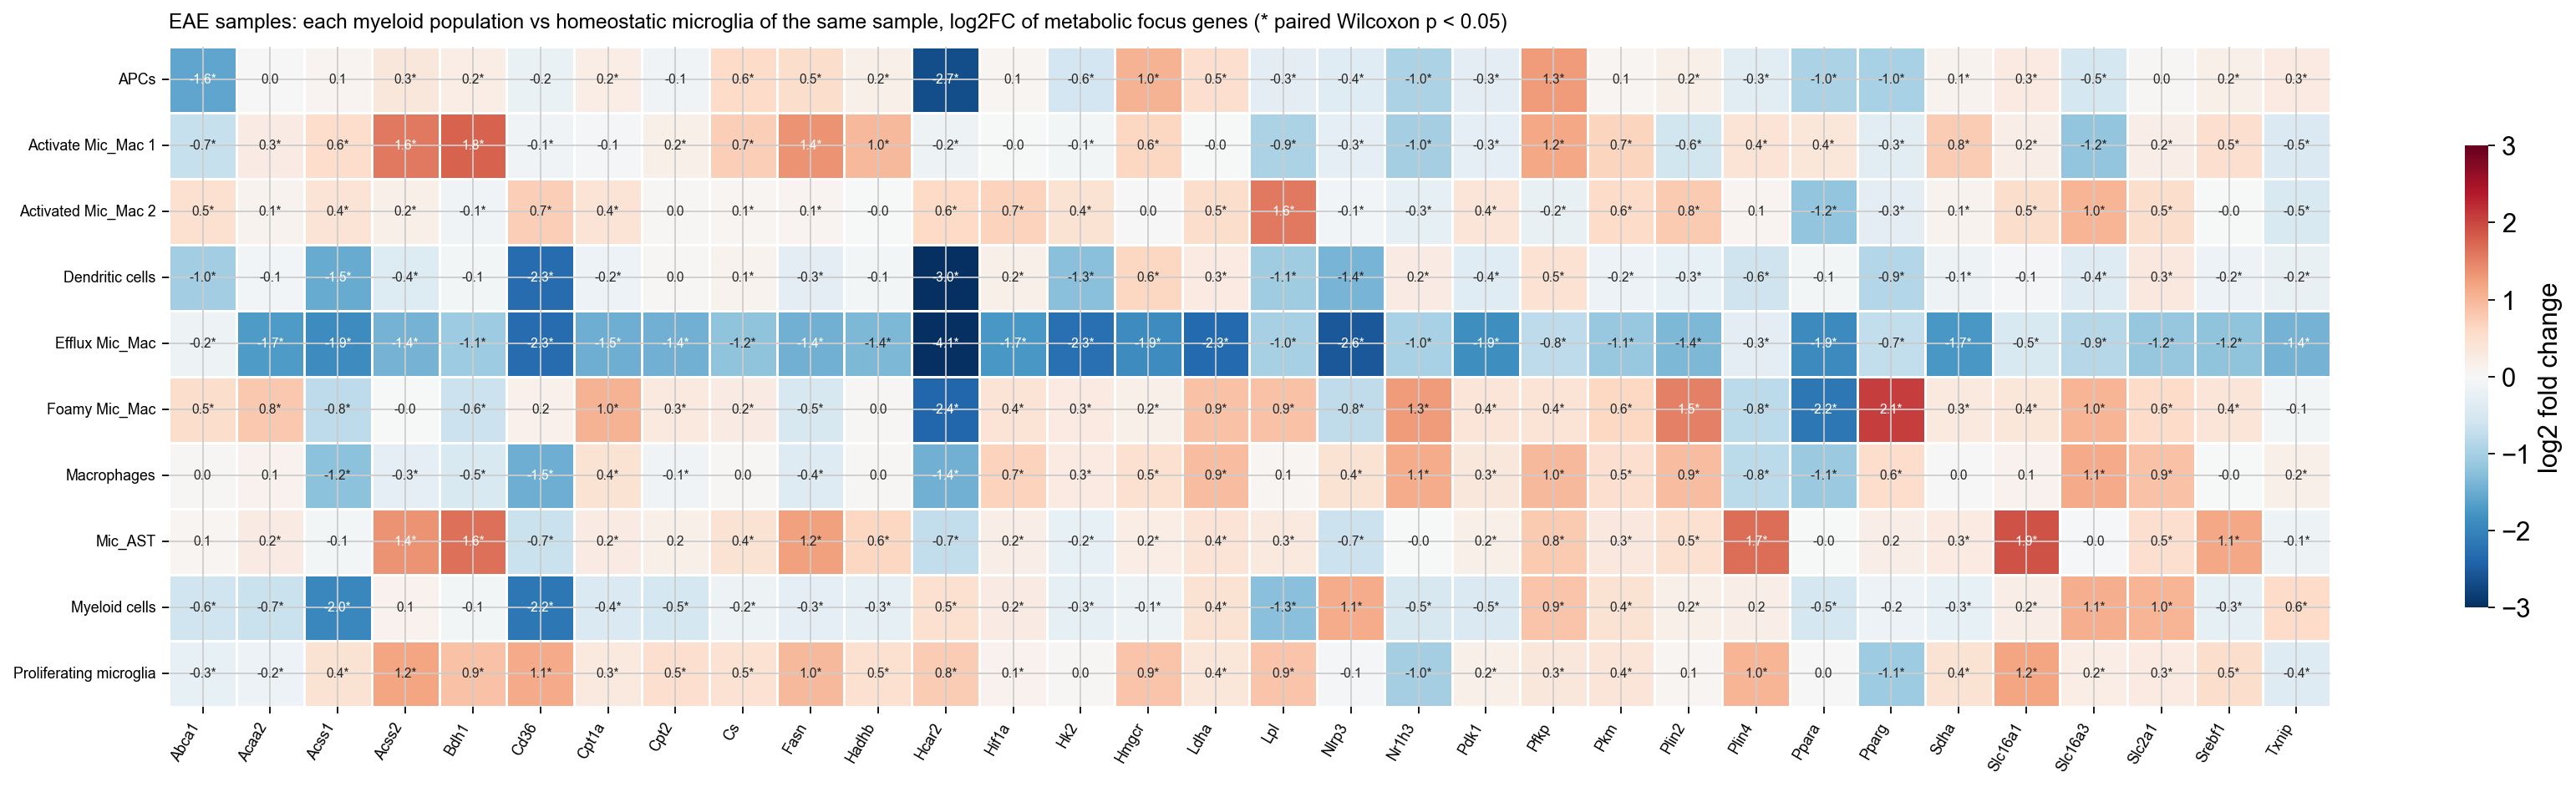

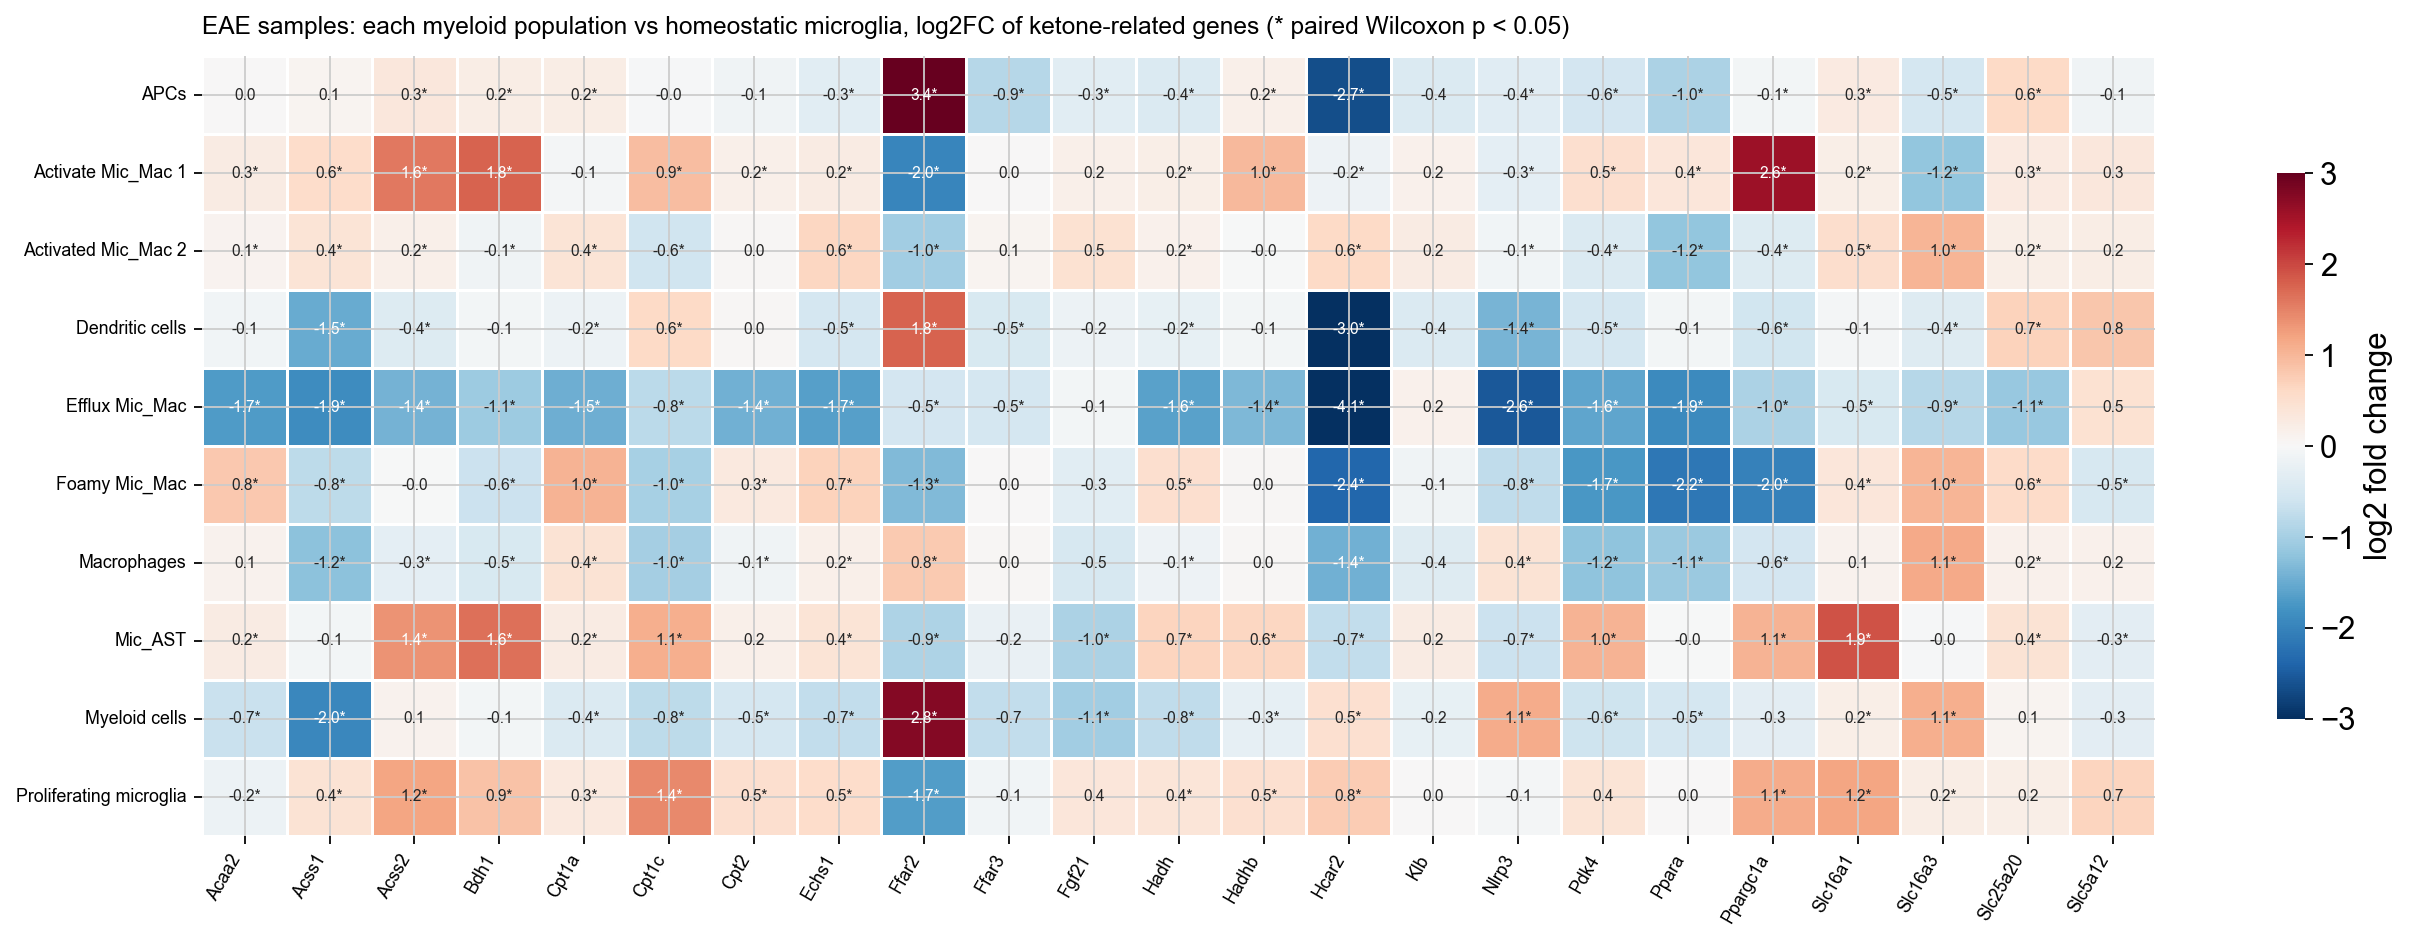

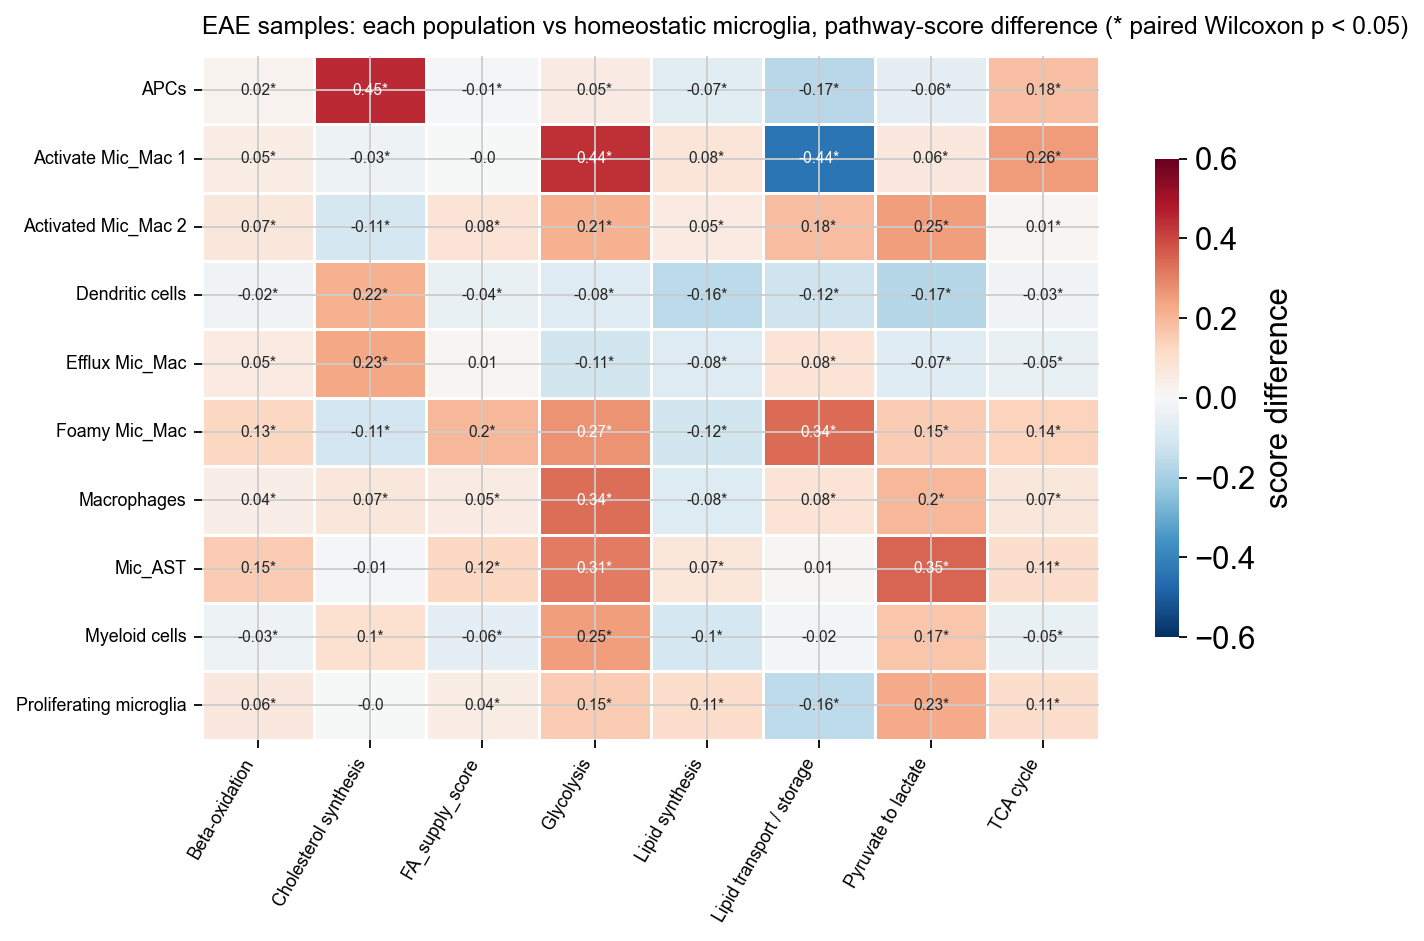

n samples with ≥20 cells of both the population and homeostatic microglia:


population
APCs                       77
Activate Mic_Mac 1         91
Activated Mic_Mac 2        70
Dendritic cells            53
Efflux Mic_Mac             71
Foamy Mic_Mac              37
Macrophages                61
Mic_AST                    73
Myeloid cells              46
Proliferating microglia    59
Name: n_samples, dtype: int64

In [6]:
eae_my = my[my.obs["condition"] == "EAE"].copy()
pops = [p for p in MYELOID if p != "Microglia"]
vs = paired_vs_reference(eae_my, focus, "sample_name", "population", pops, "Microglia"); save("vs_homeostatic_microglia_genes", vs)
star_heat(vs, "EAE samples: each myeloid population vs homeostatic microglia of the same sample, log2FC of metabolic focus genes (* paired Wilcoxon p < 0.05)", "log2 fold change", "population", "feature", "effect", "wilcoxon_p", -3, 3)
vs_k = paired_vs_reference(eae_my, ketone, "sample_name", "population", pops, "Microglia"); save("vs_homeostatic_microglia_ketone", vs_k)
star_heat(vs_k, "EAE samples: each myeloid population vs homeostatic microglia, log2FC of ketone-related genes (* paired Wilcoxon p < 0.05)", "log2 fold change", "population", "feature", "effect", "wilcoxon_p", -3, 3)
Pv = eae_my.obs[score_cols].copy(); Pv.columns = [c.replace("score::", "") for c in Pv.columns]
vs_s = paired_vs_reference(eae_my, list(Pv.columns), "sample_name", "population", pops, "Microglia", values=Pv); save("vs_homeostatic_microglia_scores", vs_s)
star_heat(vs_s, "EAE samples: each population vs homeostatic microglia, pathway-score difference (* paired Wilcoxon p < 0.05)", "score difference", "population", "feature", "effect", "wilcoxon_p", -0.6, 0.6, fmt=".2f")
print("n samples with ≥20 cells of both the population and homeostatic microglia:"); display(vs.groupby("population")["n_samples"].first())

## 5. The *Hcar2*⁺ phenotype inside each population


=== Microglia: 4671 Hcar2+ of 56065 cells; genes most enriched in Hcar2+ cells (detection ratio) then most depleted


,pathway,frac_in_Hcar2-,frac_in_Hcar2+,enrichment(+/-),spearman_rho,fisher_p
gene,,,,,,
Cd36,Fatty acid uptake / activation,0.107,0.292,2.737,0.152,0.000
Tnf,context,0.049,0.133,2.702,0.100,0.000
Ccl2,context,0.150,0.396,2.645,0.184,0.000
Mlxipl,Lipid synthesis,0.209,0.450,2.151,0.145,0.000
Cst7,context,0.321,0.608,1.897,0.167,0.000
Tmem119,context,0.386,0.729,1.888,0.171,0.000
Acsl6,Fatty acid uptake / activation,0.114,0.213,1.861,0.076,0.000
Acss1,Ketone body utilisation,0.122,0.225,1.838,0.078,0.000
P2ry12,context,0.420,0.770,1.832,0.176,0.000



=== Activate Mic_Mac 1: 1517 Hcar2+ of 18077 cells; genes most enriched in Hcar2+ cells (detection ratio) then most depleted


,pathway,frac_in_Hcar2-,frac_in_Hcar2+,enrichment(+/-),spearman_rho,fisher_p
gene,,,,,,
Ccl2,context,0.121,0.305,2.522,0.147,0.000
Tnf,context,0.035,0.082,2.334,0.065,0.000
Cd36,Fatty acid uptake / activation,0.113,0.254,2.238,0.110,0.000
Mlxipl,Lipid synthesis,0.247,0.416,1.683,0.093,0.000
Elovl1,Lipid synthesis,0.161,0.266,1.657,0.068,0.000
Cst7,context,0.347,0.565,1.628,0.116,0.000
Slc16a3,Monocarboxylate transporters,0.122,0.195,1.605,0.054,0.000
Lpl,Cholesterol / lipid transport,0.092,0.142,1.545,0.043,0.000
Ldha,Glycolysis,0.295,0.438,1.484,0.070,0.000



=== Activated Mic_Mac 2: 3187 Hcar2+ of 24097 cells; genes most enriched in Hcar2+ cells (detection ratio) then most depleted


...

,pathway,frac_in_Hcar2-,frac_in_Hcar2+,enrichment(+/-),spearman_rho,fisher_p
gene,,,,,,
Cd36,Fatty acid uptake / activation,0.041,0.088,2.167,0.078,0.000
Cst7,context,0.129,0.263,2.033,0.134,0.000
Mertk,context,0.104,0.206,1.983,0.105,0.000
Gpnmb,context,0.121,0.232,1.912,0.111,0.000
Tnf,context,0.240,0.456,1.902,0.175,0.000
Lpl,Cholesterol / lipid transport,0.043,0.079,1.854,0.054,0.000
Tmem119,context,0.039,0.071,1.831,0.058,0.000
Acsl1,Fatty acid uptake / activation,0.165,0.276,1.668,0.094,0.000
Sirt1,Nutrient sensing / regulators,0.041,0.067,1.650,0.043,0.000



=== Proliferating microglia: 1501 Hcar2+ of 7082 cells; genes most enriched in Hcar2+ cells (detection ratio) then most depleted


,pathway,frac_in_Hcar2-,frac_in_Hcar2+,enrichment(+/-),spearman_rho,fisher_p
gene,,,,,,
Tnf,context,0.101,0.203,2.007,0.121,0.000
Mlxipl,Lipid synthesis,0.263,0.469,1.784,0.158,0.000
Lss,Cholesterol synthesis,0.082,0.143,1.753,0.072,0.000
Ldlr,Cholesterol / lipid transport,0.108,0.186,1.726,0.089,0.000
Cd36,Fatty acid uptake / activation,0.360,0.604,1.679,0.171,0.000
Ccl2,context,0.428,0.699,1.633,0.216,0.000
Nr1h2,Cholesterol / lipid transport,0.119,0.194,1.630,0.072,0.000
Opa1,Mitochondrial biogenesis / dynamics,0.181,0.289,1.595,0.091,0.000
Elovl1,Lipid synthesis,0.270,0.430,1.589,0.116,0.000



=== Foamy Mic_Mac: 291 Hcar2+ of 12961 cells; genes most enriched in Hcar2+ cells (detection ratio) then most depleted


,pathway,frac_in_Hcar2-,frac_in_Hcar2+,enrichment(+/-),spearman_rho,fisher_p
gene,,,,,,
Acss1,Ketone body utilisation,0.101,0.192,1.909,0.040,0.000
Acss2,Ketone body utilisation,0.062,0.117,1.895,0.031,0.001
Cst7,context,0.347,0.632,1.823,0.093,0.000
Top2a,context,0.051,0.093,1.817,0.027,0.003
Tmem119,context,0.086,0.151,1.766,0.032,0.000
Ccr2,context,0.041,0.072,1.748,0.022,0.017
Acsl6,Fatty acid uptake / activation,0.055,0.093,1.679,0.023,0.009
Fasn,Lipid synthesis,0.138,0.216,1.565,0.030,0.000
Sirt3,Nutrient sensing / regulators,0.051,0.079,1.536,0.018,0.044


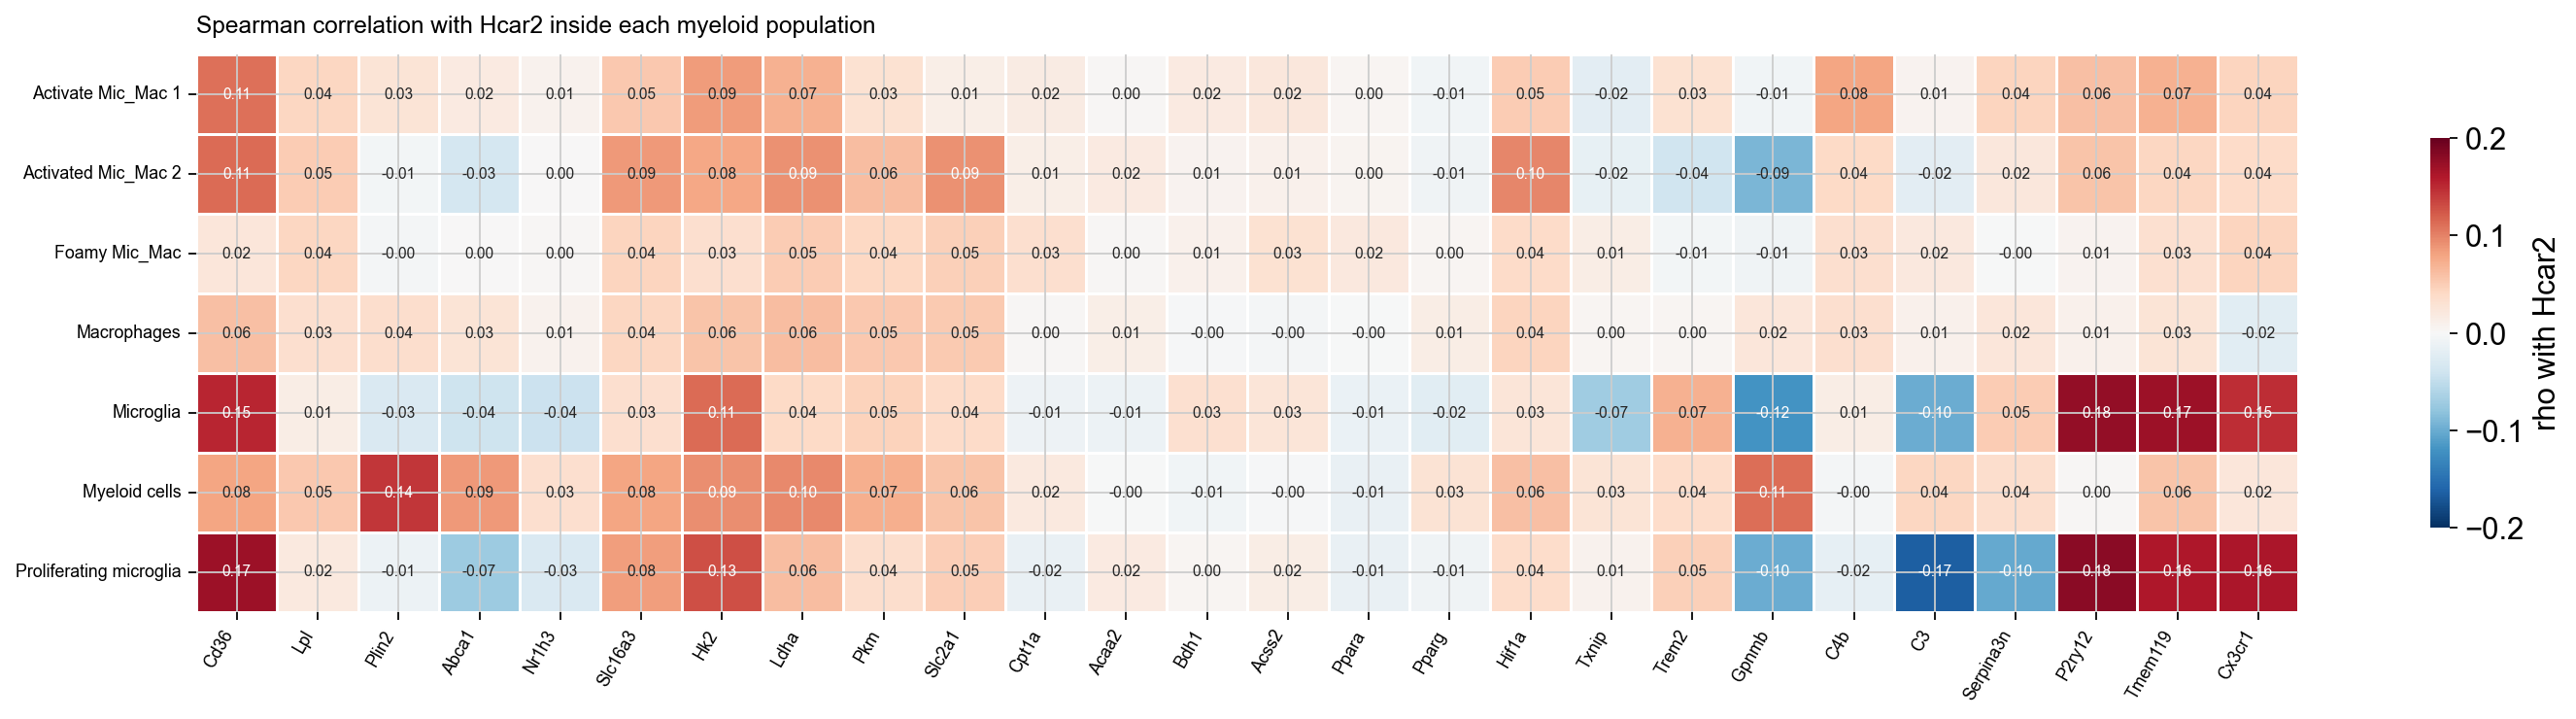

<Axes: title={'left': 'Spearman correlation with Hcar2 inside each myeloid population'}>

In [7]:
rows = []
for p in ["Microglia", "Activate Mic_Mac 1", "Activated Mic_Mac 2", "Macrophages", "Myeloid cells", "Proliferating microglia", "Foamy Mic_Mac"]:
    sub = my[my.obs["population"] == p]
    if (om.expr(sub, "Hcar2") > 0).sum() < 100:
        continue
    co = om.coexpression_with_anchor(sub, "Hcar2", [g for g in metab + markers if g != "Hcar2"], min_pos=100); co["population"] = p; co["n_cells"] = sub.n_obs; co["n_Hcar2+"] = int((om.expr(sub, "Hcar2") > 0).sum())
    rows.append(co.reset_index()); del sub
HC = pd.concat(rows, ignore_index=True); save("Hcar2_phenotype", HC)
for p in HC.population.unique():
    h = HC[HC.population == p].set_index("gene")
    h = h[(h["frac_in_Hcar2+"] >= 0.05) | (h["frac_in_Hcar2-"] >= 0.05)]
    top_up = h.sort_values("enrichment(+/-)", ascending=False).head(15); top_dn = h.sort_values("enrichment(+/-)").head(8)
    print(f"\n=== {p}: {int(h['n_Hcar2+'].iloc[0])} Hcar2+ of {int(h['n_cells'].iloc[0])} cells; genes most enriched in Hcar2+ cells (detection ratio) then most depleted")
    display(pd.concat([top_up, top_dn])[["pathway", "frac_in_Hcar2-", "frac_in_Hcar2+", "enrichment(+/-)", "spearman_rho", "fisher_p"]].round(3))
piv = HC.pivot(index="gene", columns="population", values="spearman_rho")
sel = piv.loc[[g for g in ["Nlrp3", "Cd36", "Lpl", "Plin2", "Abca1", "Nr1h3", "Slc16a3", "Hk2", "Ldha", "Pkm", "Slc2a1", "Cpt1a", "Acaa2", "Bdh1", "Acss2", "Ppara", "Pparg", "Hif1a", "Txnip", "Trem2", "Spp1", "Gpnmb", "Lgals3", "Il1b", "C4b", "C3", "Serpina3n", "P2ry12", "Tmem119", "Cx3cr1"] if g in piv.index]]
heat(sel.T, "Spearman correlation with Hcar2 inside each myeloid population", "rho with Hcar2", fmt=".2f", cmap="RdBu_r", center=0, vmin=-0.2, vmax=0.2, row_labels=list(sel.columns))

## 6. Lesion distance per population

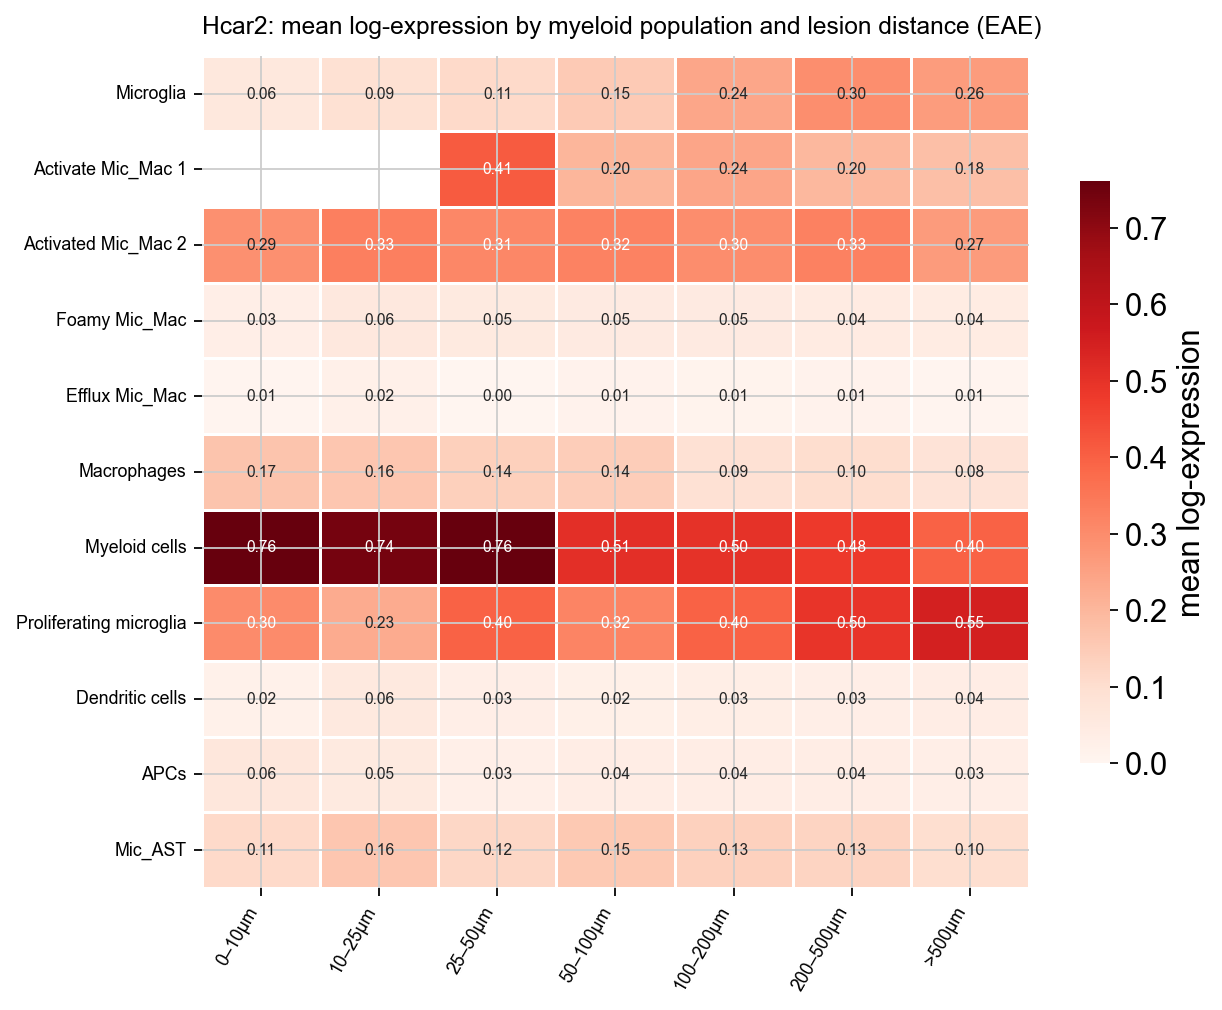

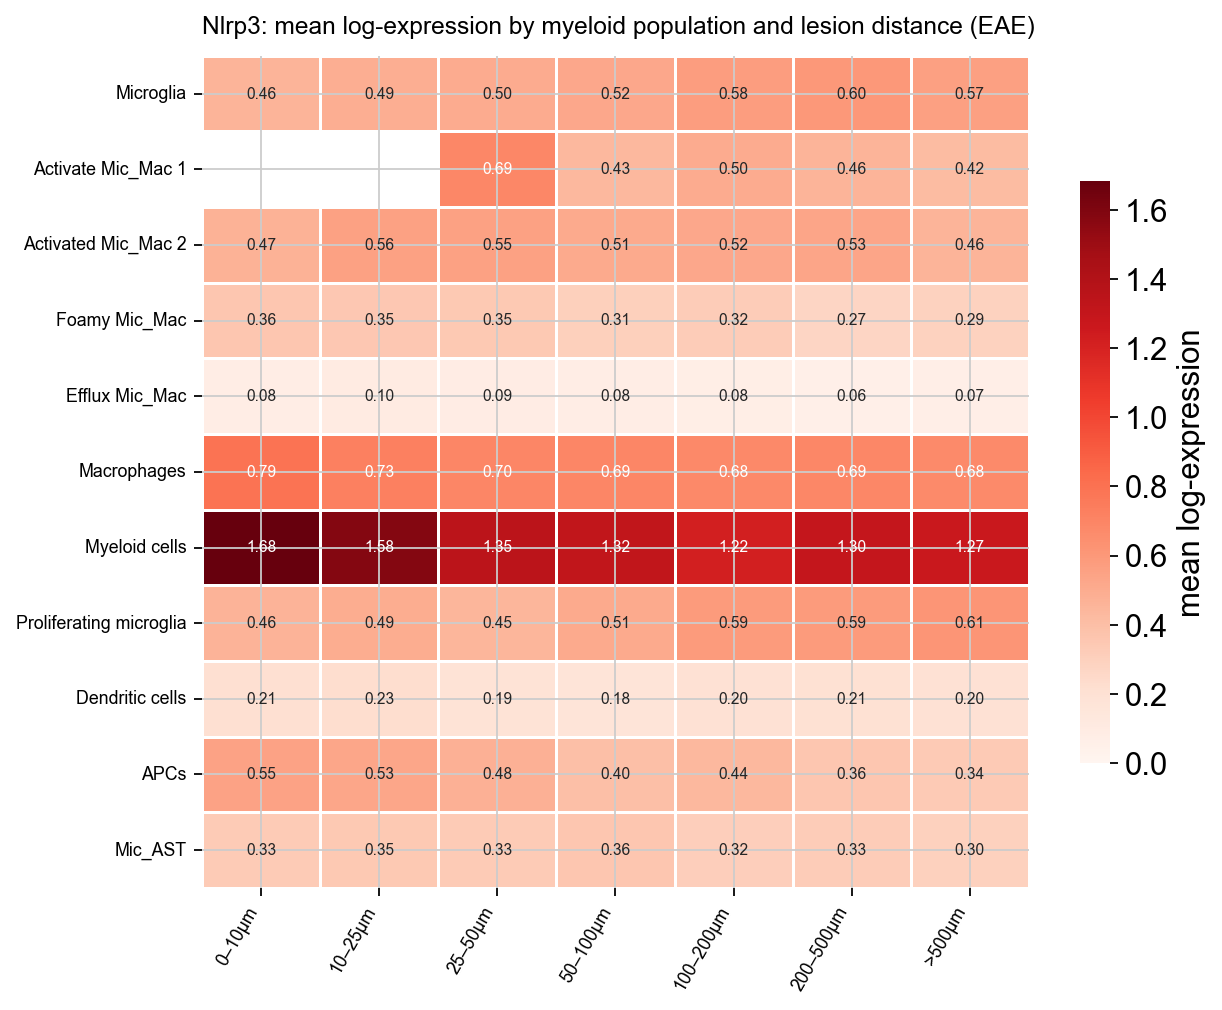

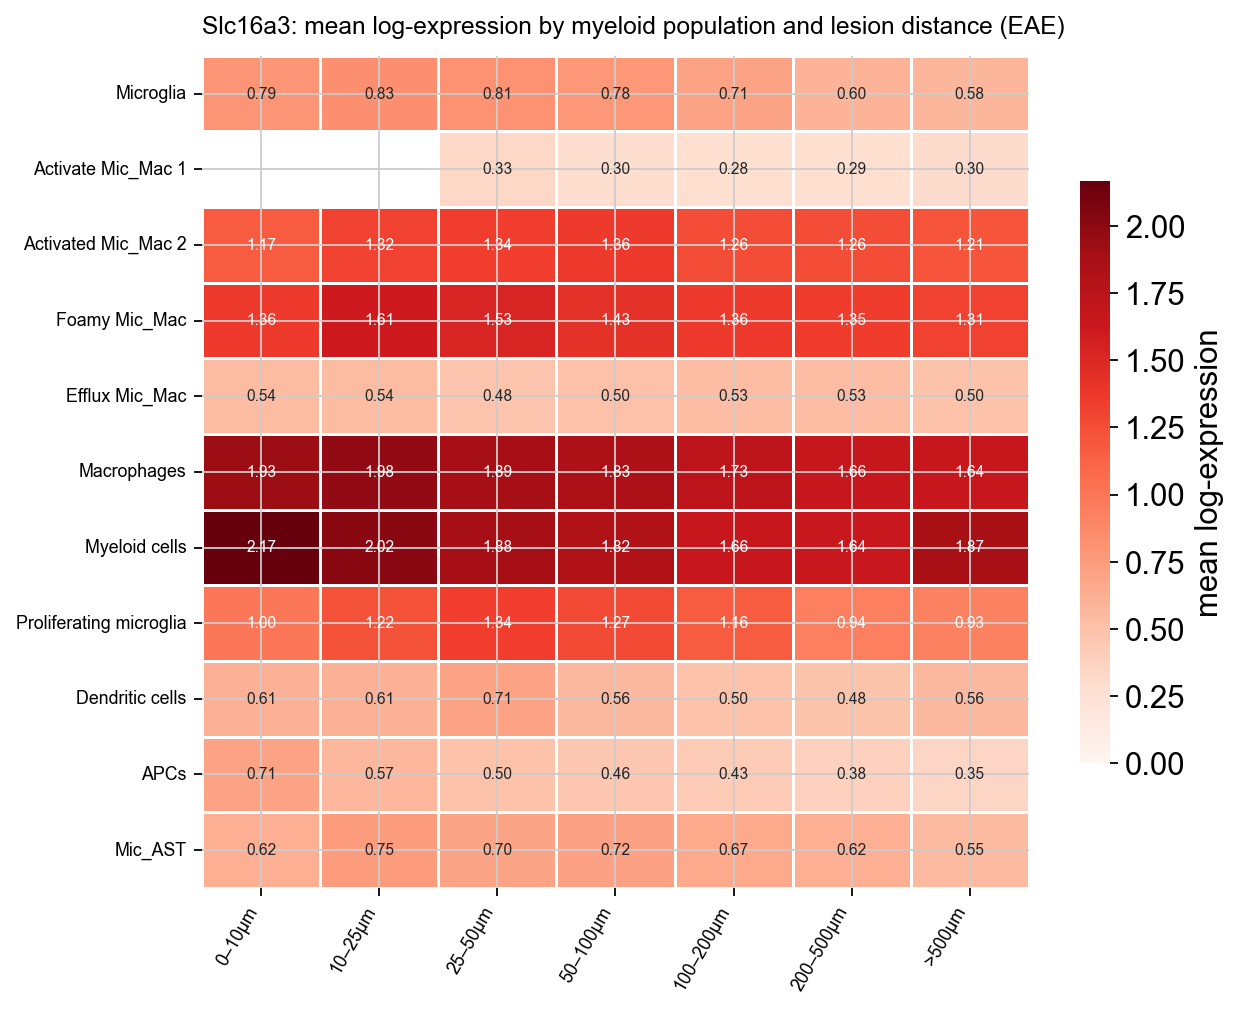

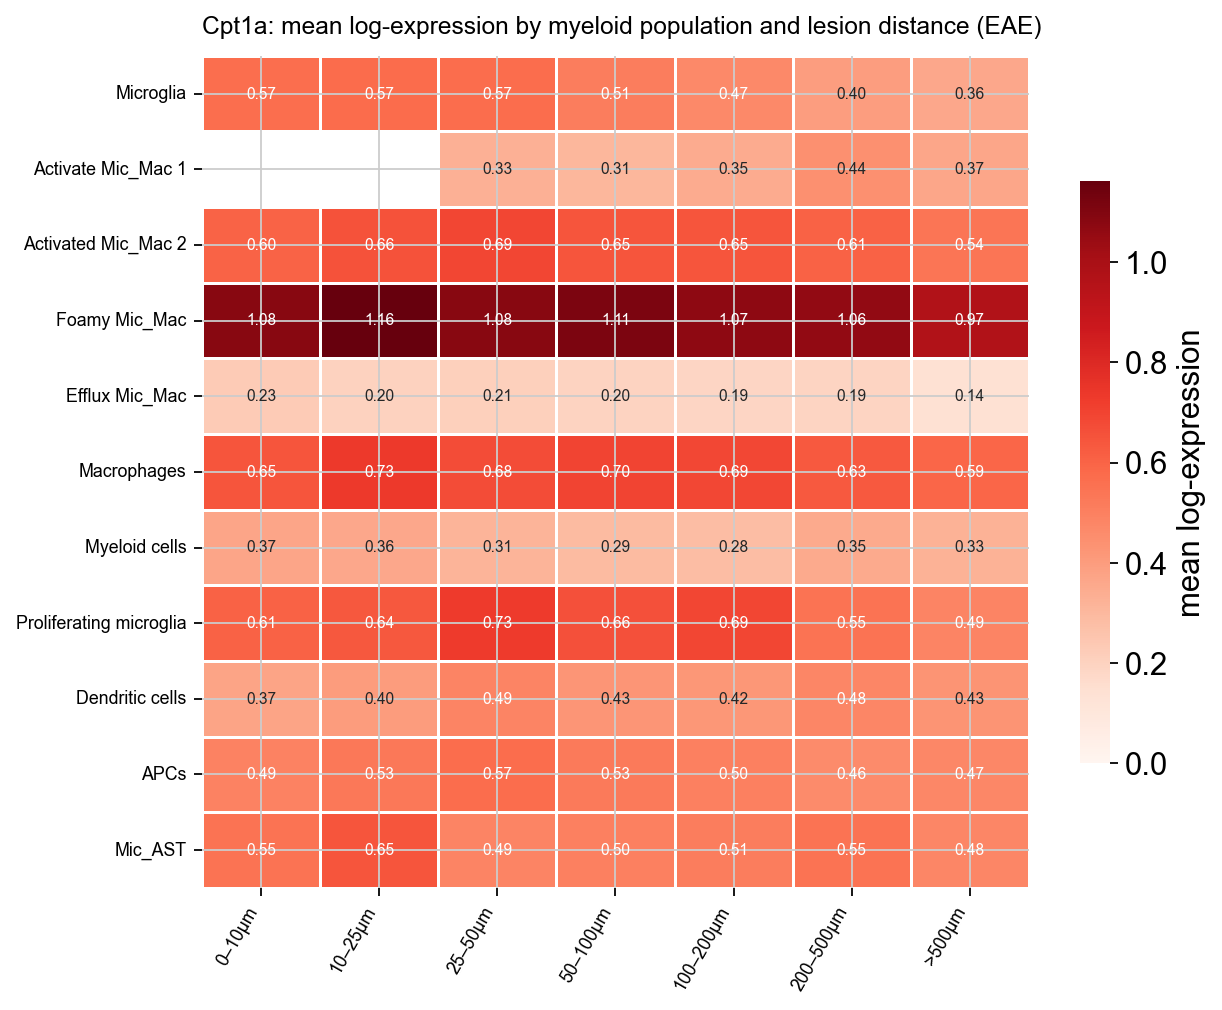

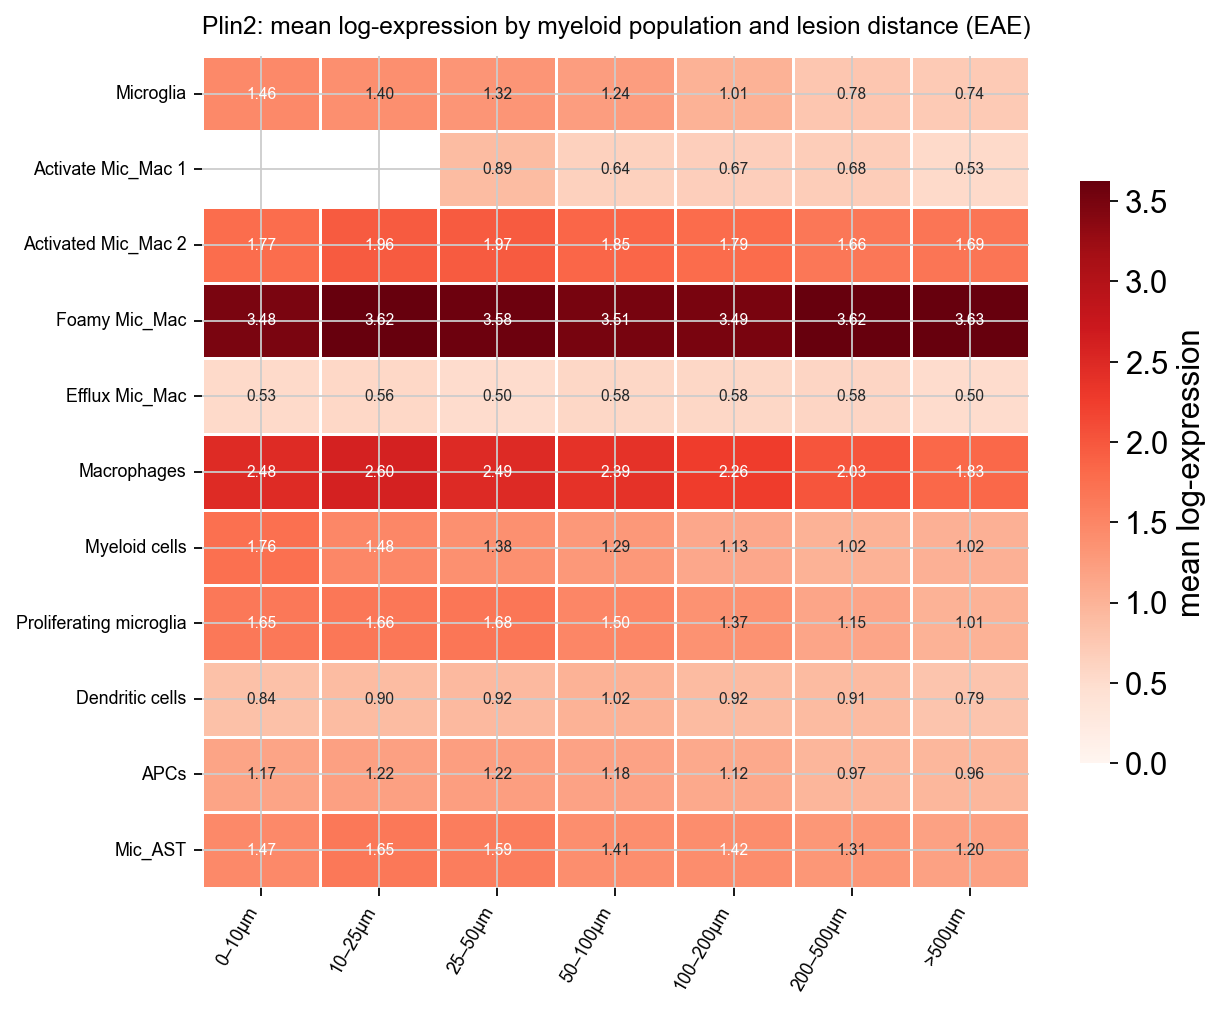

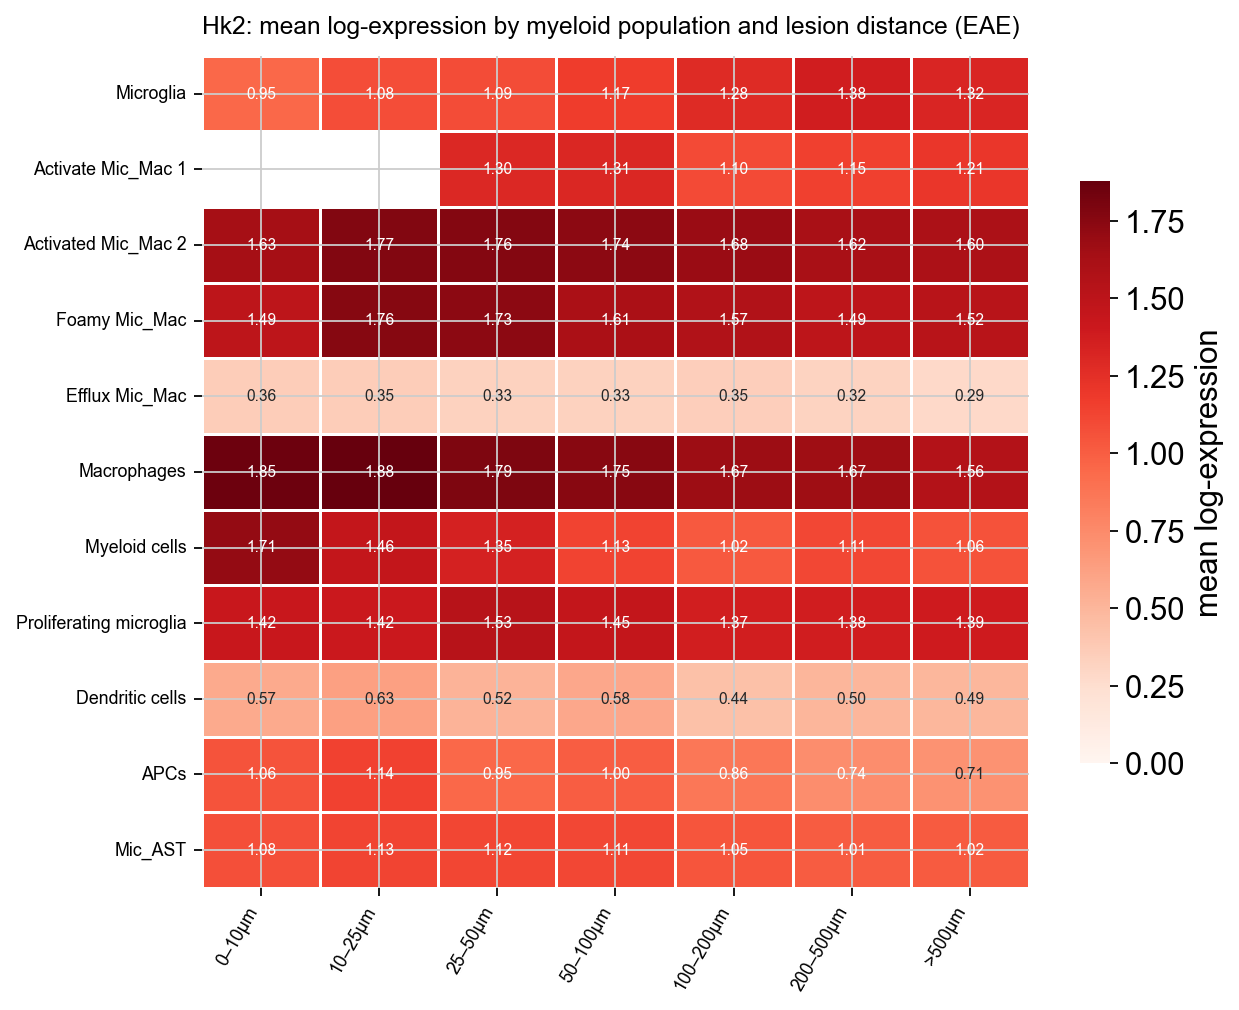

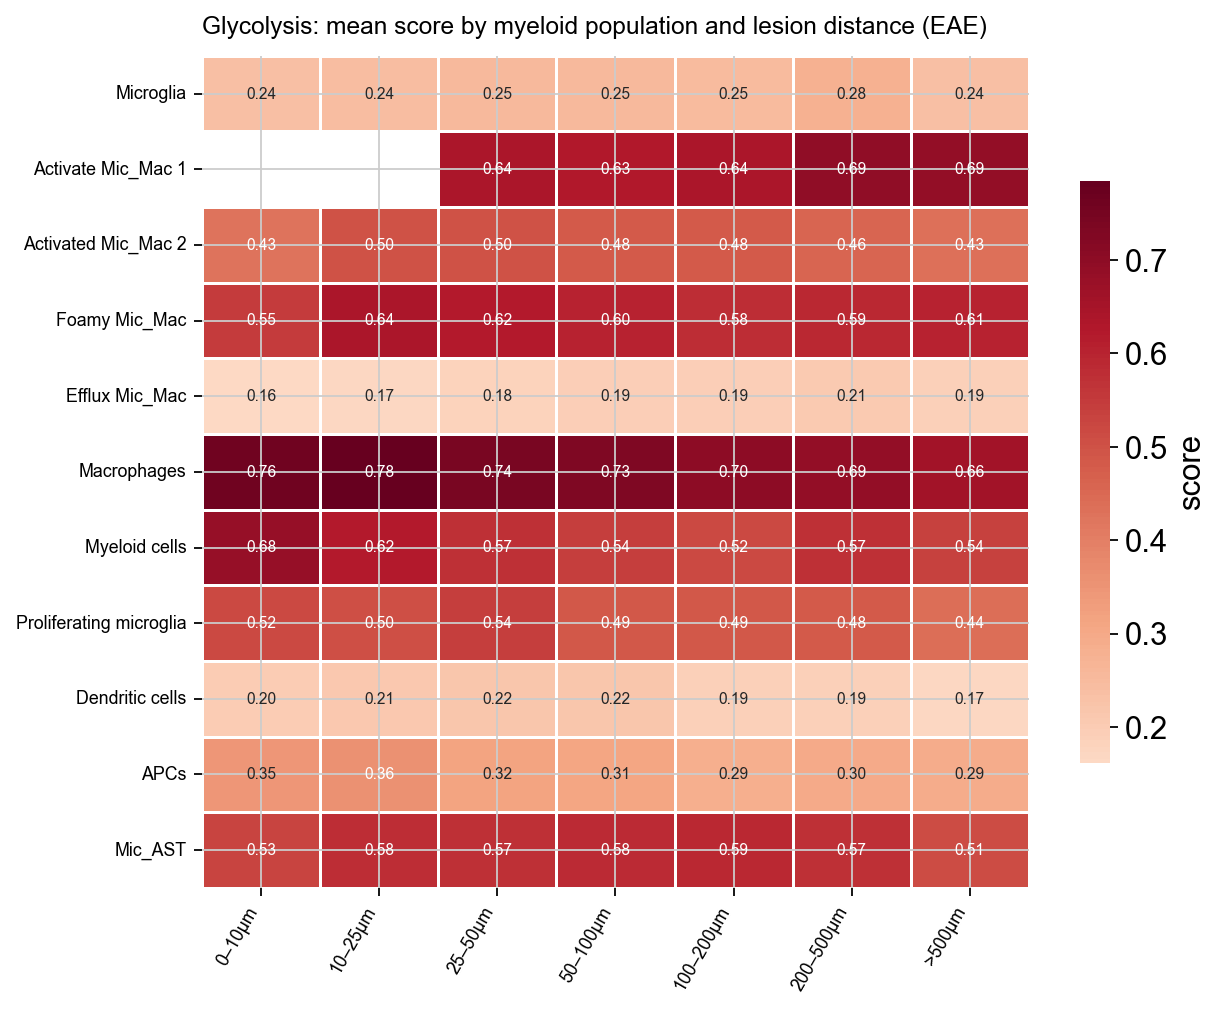

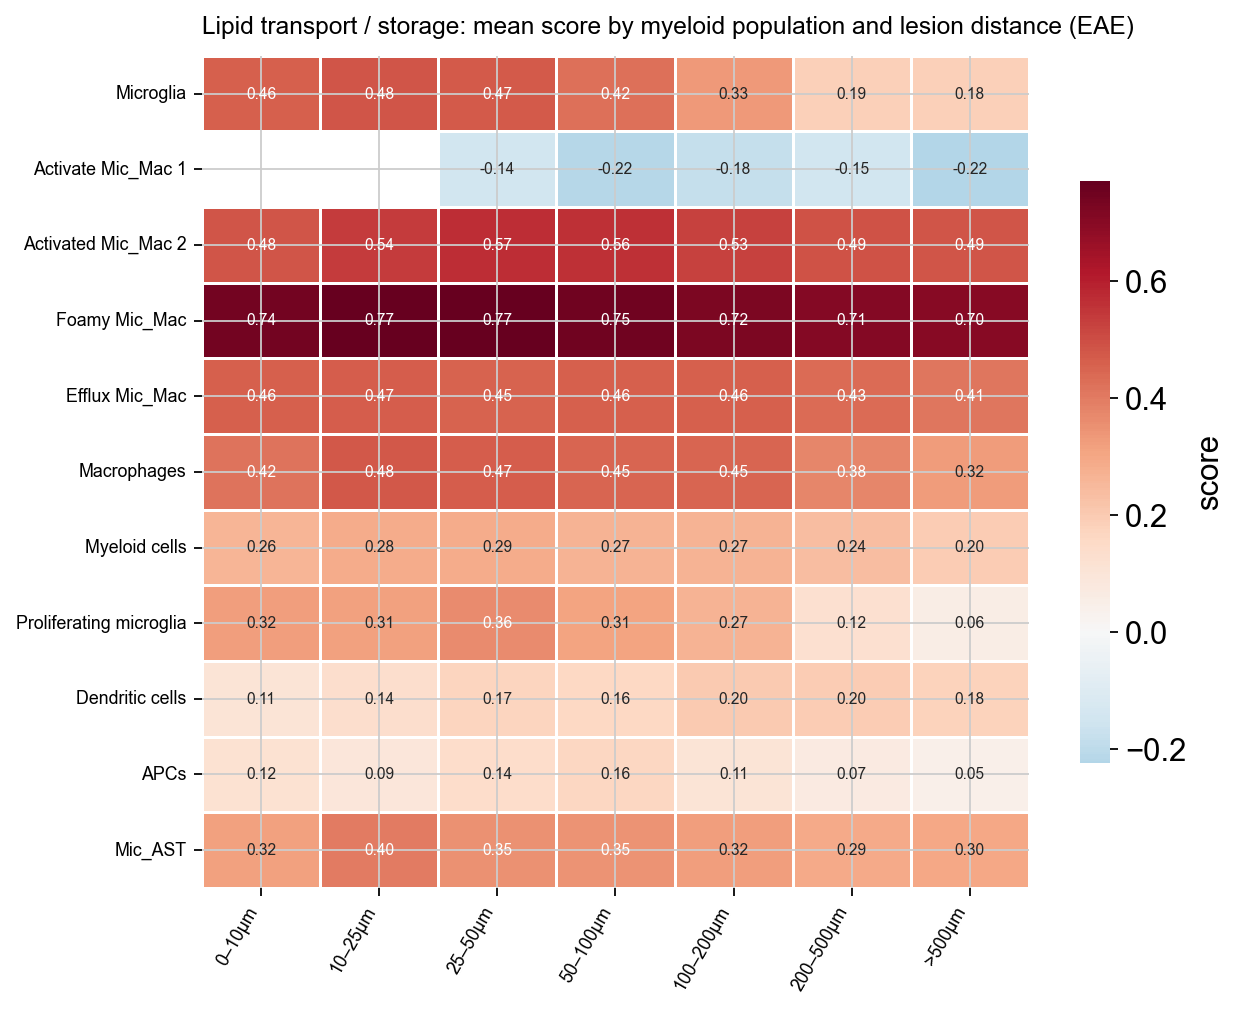

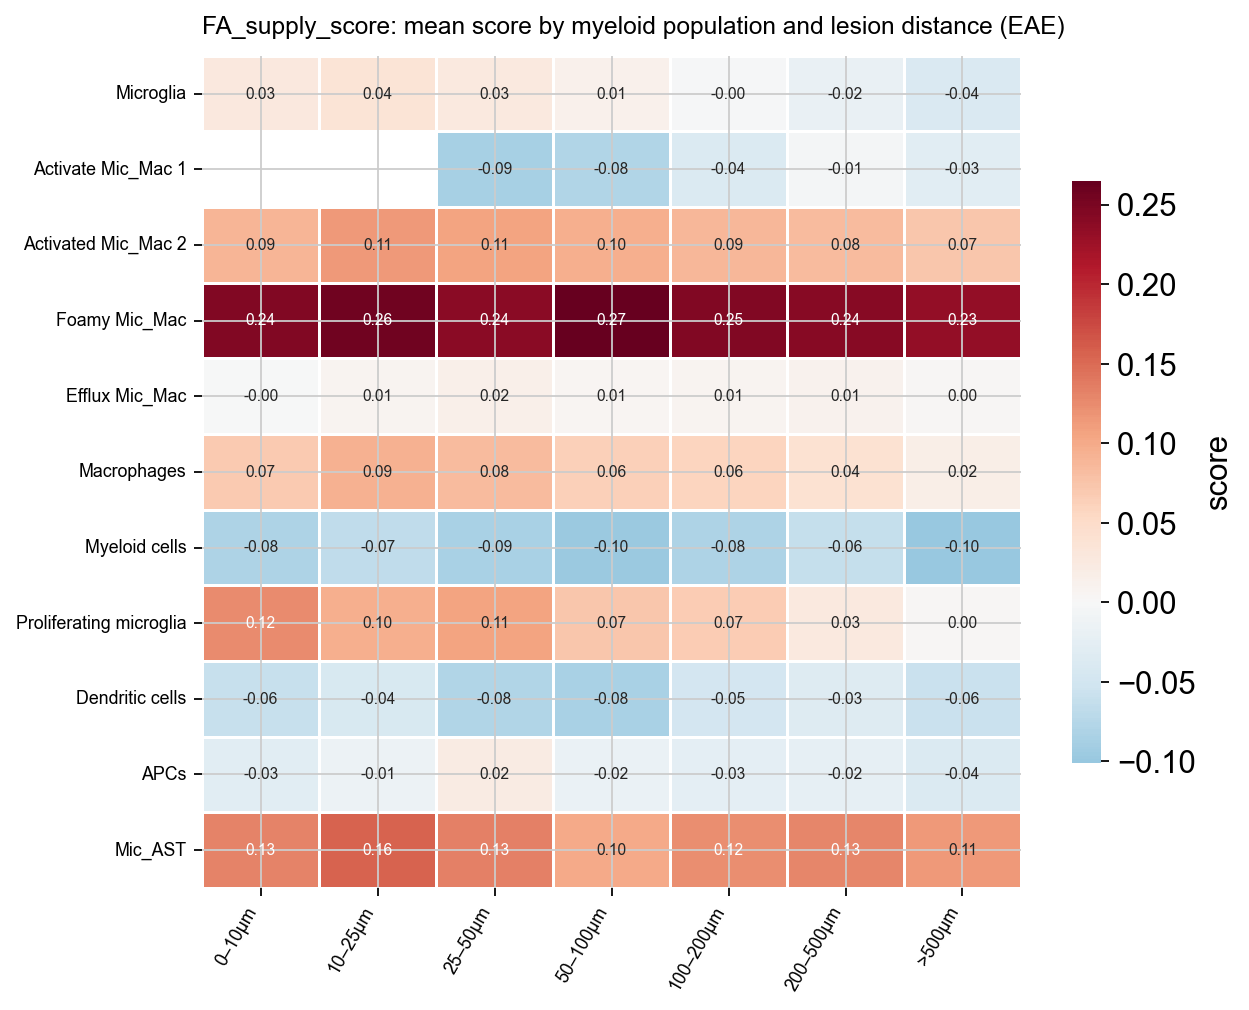

In [8]:
sub = my[m_eae]
key_ld = [g for g in ["Hcar2", "Nlrp3", "Slc16a3", "Slc16a1", "Cpt1a", "Bdh1", "Acss2", "Plin2", "Cd36", "Lpl", "Hk2", "Ldha", "Pkm", "Slc2a1", "Hif1a"] if g in sub.var_names]
dfl = om.expr_df(sub, key_ld); keys = [sub.obs["population"].astype(str).values, sub.obs["lesion_distance_bin"].astype(str).values]
ct_bin = dfl.groupby(keys).mean(); n_bin = sub.obs.groupby(keys).size(); ct_bin = ct_bin[n_bin >= 50]; ct_bin.index.names = ["population", "bin"]; save("lesion_distance_genes", ct_bin)
for gname in ["Hcar2", "Nlrp3", "Slc16a3", "Cpt1a", "Plin2", "Hk2"]:
    m = ct_bin[gname].unstack("bin").reindex(index=MYELOID, columns=bins).dropna(how="all")
    heat(m, f"{gname}: mean log-expression by myeloid population and lesion distance (EAE)", "mean log-expression", fmt=".2f", cmap="Reds", center=None, vmin=0, vmax=None, row_labels=list(m.index))
sc_bin = sub.obs.groupby(keys)[score_cols].mean(); sc_bin = sc_bin[n_bin >= 50]; sc_bin.columns = [c.replace("score::", "") for c in sc_bin.columns]; sc_bin.index.names = ["population", "bin"]; save("lesion_distance_scores", sc_bin)
for pw in ["Glycolysis", "Lipid transport / storage", "FA_supply_score"]:
    m = sc_bin[pw].unstack("bin").reindex(index=MYELOID, columns=bins).dropna(how="all")
    heat(m, f"{pw}: mean score by myeloid population and lesion distance (EAE)", "score", fmt=".2f", cmap="RdBu_r", center=0, row_labels=list(m.index))
del sub, dfl

## 7. Disease course

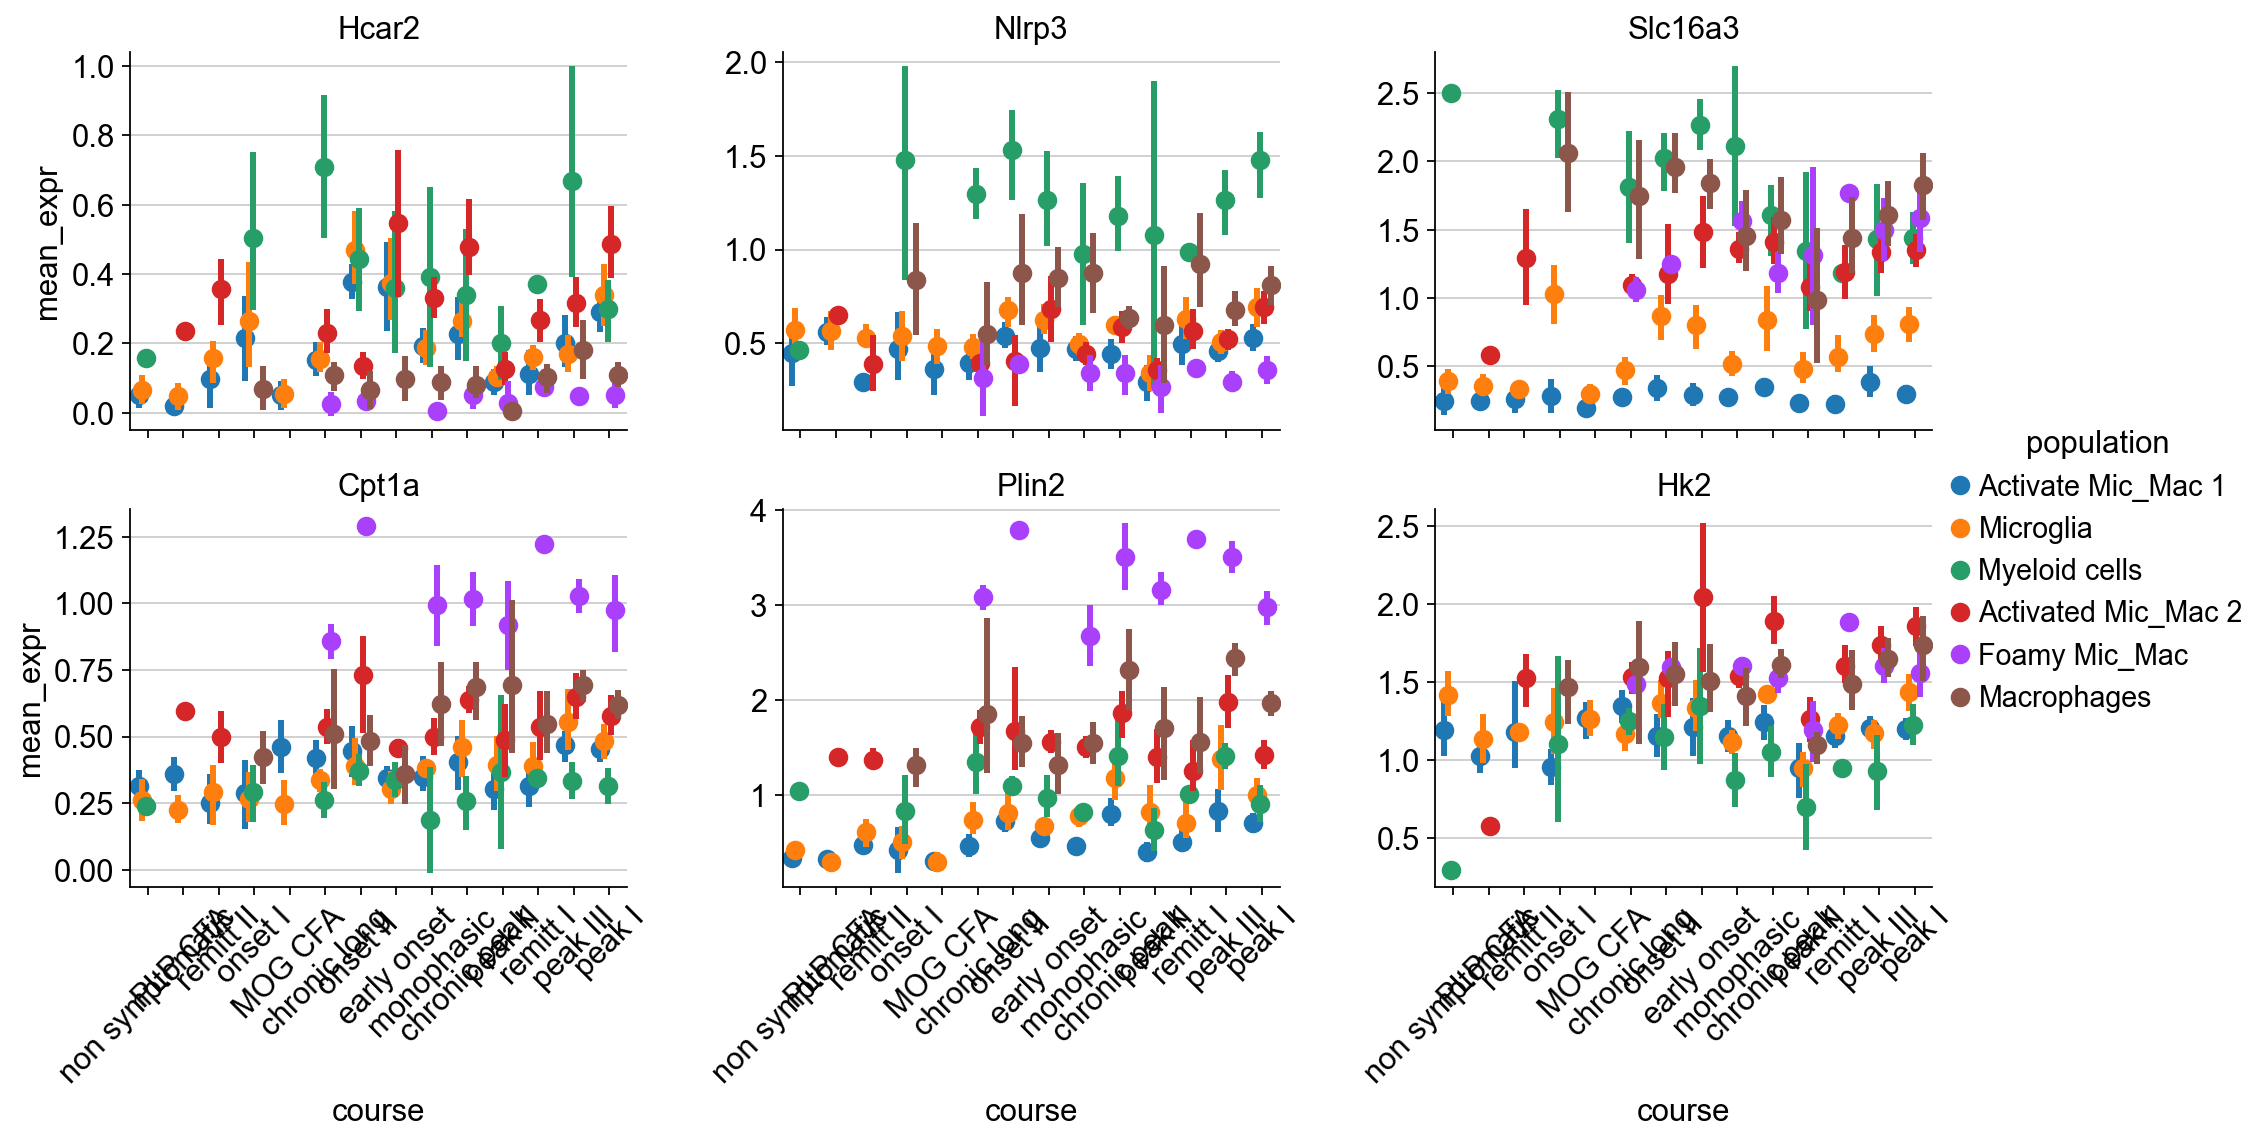

per-sample mean expression vs lesion fraction, EAE samples:


population,APCs,Activate Mic_Mac 1,Activated Mic_Mac 2,Dendritic cells,Efflux Mic_Mac,Foamy Mic_Mac,Macrophages,Mic_AST,Microglia,Myeloid cells,Proliferating microglia
gene,,,,,,,,,,,
Bdh1,0.05,-0.05,-0.26,0.06,0.12,-0.10,-0.19,-0.28,-0.30,0.00,-0.14
Cpt1a,0.09,0.24,0.24,0.17,0.34,0.10,0.38,0.32,0.60,-0.01,0.43
Hcar2,0.16,0.14,0.17,-0.09,0.17,-0.08,0.19,0.03,0.10,0.07,-0.27
Hk2,0.25,-0.05,0.37,-0.10,0.32,0.22,0.22,0.12,0.01,0.11,-0.08
Nlrp3,-0.05,0.11,0.46,-0.09,0.15,-0.05,-0.07,0.00,0.08,0.02,-0.16
Plin2,0.15,0.39,-0.03,0.11,0.42,0.07,0.42,0.20,0.61,0.19,0.53
Slc16a3,0.03,-0.01,0.09,-0.09,0.03,0.12,-0.14,0.30,0.21,-0.54,0.19


In [9]:
pb = om.pseudobulk(my, [g for g in ["Hcar2", "Nlrp3", "Slc16a3", "Cpt1a", "Plin2", "Cd36", "Lpl", "Hk2", "Ldha", "Bdh1", "Acss2"] if g in my.var_names], "sample_name", ["population", "condition"])
n = my.obs.groupby(["sample_name", "population"], observed=True).size().rename("n_cells").reset_index(); n[["sample_name", "population"]] = n[["sample_name", "population"]].astype(str)
pb = pb.merge(n, on=["sample_name", "population"]).query("n_cells >= 20").merge(meta[["course", "model", "frac_lesion"]], left_on="sample_name", right_index=True)
course_tab = pb.groupby(["population", "course"], observed=True)[["Hcar2", "Nlrp3", "Slc16a3", "Cpt1a", "Plin2", "Cd36", "Lpl", "Hk2", "Ldha"]].mean().round(3); save("pseudobulk_by_course", course_tab)
tidy = pb[pb.population.isin(["Microglia", "Activate Mic_Mac 1", "Activated Mic_Mac 2", "Macrophages", "Foamy Mic_Mac", "Myeloid cells"])].melt(id_vars=["sample_name", "population", "condition", "course", "model", "frac_lesion", "n_cells"], value_vars=["Hcar2", "Nlrp3", "Slc16a3", "Cpt1a", "Plin2", "Hk2"], var_name="gene", value_name="mean_expr")
g = sns.catplot(data=tidy, x="course", y="mean_expr", hue="population", col="gene", col_wrap=3, kind="point", order=order_c, dodge=0.5, errorbar=("ci", 95), linestyle="none", height=3.2, aspect=1.3, sharey=False)
for ax in g.axes.flat:
    ax.tick_params(axis="x", rotation=45)
g.set_titles("{col_name}"); plt.show()
rows = []
for p in MYELOID:
    e = pb[(pb.population == p) & (pb.condition == "EAE")]
    for gname in ["Hcar2", "Nlrp3", "Slc16a3", "Cpt1a", "Plin2", "Hk2", "Bdh1"]:
        if len(e) >= 8 and e[gname].std() > 0:
            rho, pv = stats.spearmanr(e["frac_lesion"], e[gname]); rows.append({"population": p, "gene": gname, "n_samples": len(e), "rho_vs_lesion_fraction": rho, "p": pv})
gb = pd.DataFrame(rows); save("gene_vs_lesion_burden", gb)
print("per-sample mean expression vs lesion fraction, EAE samples:"); display(gb.pivot(index="gene", columns="population", values="rho_vs_lesion_fraction").round(2))

## 8. Spatial: which myeloid populations surround DA oligodendrocytes, and are their *Hcar2*⁺ cells enriched there?

,source,target,n_samples,median_ratio,frac_samples_gt1,wilcoxon_p,lesion_matched_median_ratio,lesion_matched_p
0,DA vs homeostatic oligodendrocytes,Microglia,92,1.619,0.989,0.000,1.388,0.000
1,DA vs homeostatic oligodendrocytes,Microglia Hcar2+,84,1.273,0.833,0.000,1.172,0.000
2,DA vs homeostatic oligodendrocytes,Activate Mic_Mac 1,92,0.376,0.033,0.000,0.455,0.000
3,DA vs homeostatic oligodendrocytes,Activate Mic_Mac 1 Hcar2+,56,0.384,0.071,0.000,0.406,0.000
4,DA vs homeostatic oligodendrocytes,Activated Mic_Mac 2,73,2.781,0.959,0.000,1.781,0.000
5,DA vs homeostatic oligodendrocytes,Activated Mic_Mac 2 Hcar2+,61,2.491,0.951,0.000,1.816,0.000
6,DA vs homeostatic oligodendrocytes,Foamy Mic_Mac,46,3.075,0.935,0.000,1.821,0.000
7,DA vs homeostatic oligodendrocytes,Efflux Mic_Mac,82,3.274,0.927,0.000,2.582,0.000
8,DA vs homeostatic oligodendrocytes,Macrophages,71,2.782,0.915,0.000,1.670,0.004
9,DA vs homeostatic oligodendrocytes,Macrophages Hcar2+,25,2.531,0.880,0.000,1.332,0.018


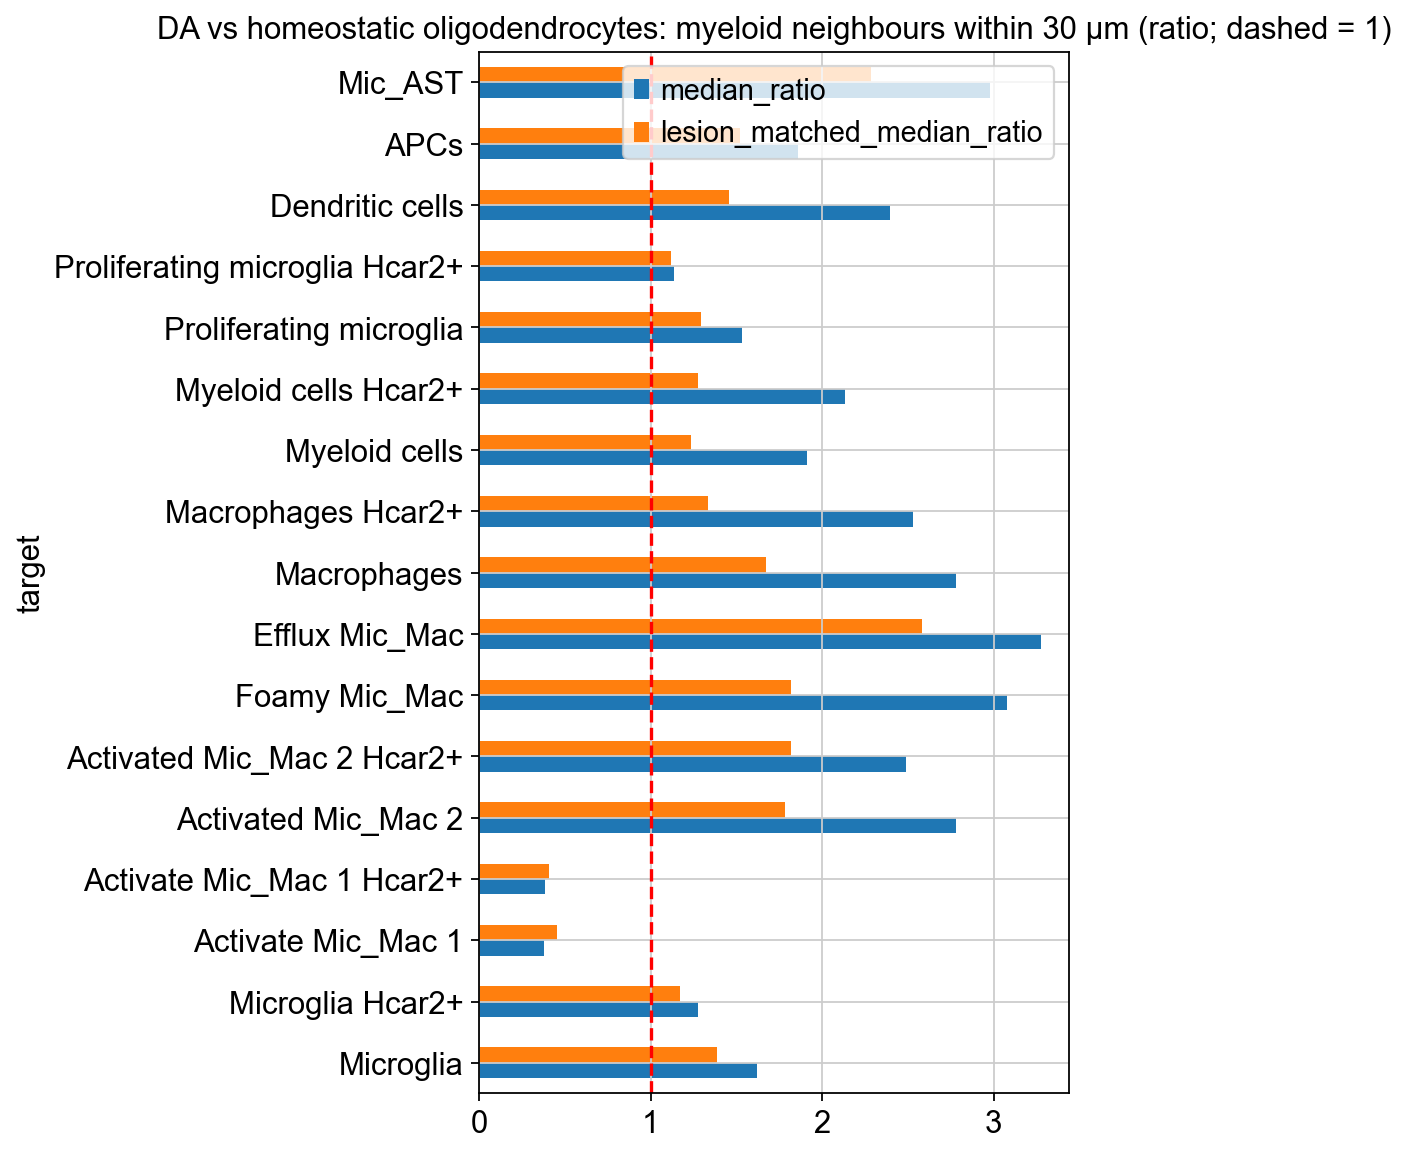

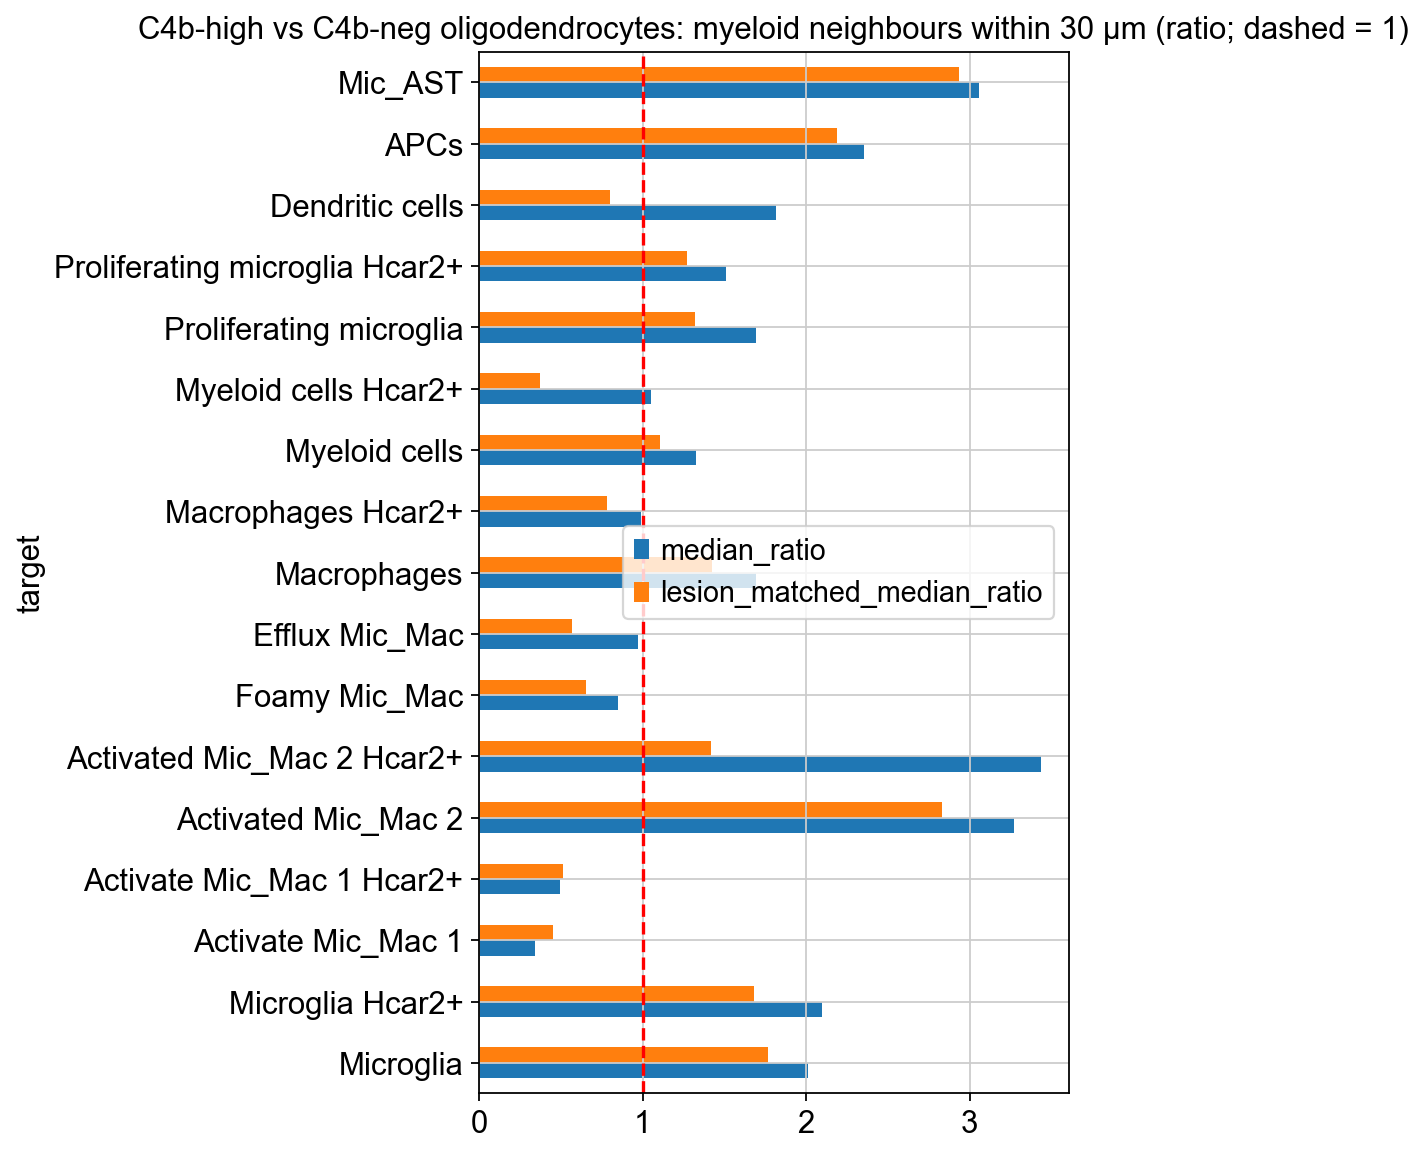

In [10]:
eae = ad[ad.obs["condition"] == "EAE"].copy()
ct_e = eae.obs["cell_type"].values; c4b_e = om.expr(eae, "C4b"); is_ol = np.isin(ct_e, ["Oligodendrocytes", "DA Oligodendrocytes"]); thr = np.quantile(c4b_e[is_ol & (c4b_e > 0)], 0.75)
sources = {"DA vs homeostatic oligodendrocytes": (ct_e == "DA Oligodendrocytes", ct_e == "Oligodendrocytes"), "C4b-high vs C4b-neg oligodendrocytes": (is_ol & (c4b_e >= thr), is_ol & (c4b_e == 0))}
hcar2 = om.expr(eae, "Hcar2") > 0; strata = eae.obs["lesion_distance_bin"].astype(str).values
rows = []
for sname, (sa, sb) in sources.items():
    for p in MYELOID:
        for lab, tgt in [(p, ct_e == p), (p + " Hcar2+", (ct_e == p) & hcar2)]:
            if tgt.sum() < 500:
                continue
            j = om.compare_neighbourhoods(eae, "sample_name", sa, sb, tgt, "A", "B", radius=30.0, verbose=False)
            ratios = []
            for b in bins:
                m = strata == b
                A = om.neighbourhood_fraction(eae, "sample_name", sa & m, tgt, 30.0, min_source=20); B = om.neighbourhood_fraction(eae, "sample_name", sb & m, tgt, 30.0, min_source=20)
                jj = A[["frac_target_neighbours"]].join(B[["frac_target_neighbours"]], lsuffix="_A", rsuffix="_B", how="inner"); jj = jj[jj.iloc[:, 1] > 0]
                ratios += [(smp, r_ / rb) for smp, (r_, rb) in zip(jj.index, jj.values)]
            ps = pd.DataFrame(ratios, columns=["sample", "ratio"]).groupby("sample")["ratio"].median() if ratios else pd.Series(dtype=float)
            rows.append({"source": sname, "target": lab, "n_samples": len(j), "median_ratio": j["ratio"].median(), "frac_samples_gt1": (j["ratio"] > 1).mean(),
                         "wilcoxon_p": stats.wilcoxon(j.iloc[:, 0], j.iloc[:, 1]).pvalue if len(j) >= 3 else np.nan,
                         "lesion_matched_median_ratio": ps.median() if len(ps) else np.nan, "lesion_matched_p": stats.wilcoxon(np.log(ps.clip(lower=1e-3))).pvalue if len(ps) >= 3 else np.nan})
NB = pd.DataFrame(rows); save("neighbourhoods", NB); display(NB.round(3))
for sname in sources:
    d = NB[NB.source == sname].set_index("target")[["median_ratio", "lesion_matched_median_ratio"]]
    d.plot.barh(figsize=(7, 0.35 * len(d) + 1.5), title=f"{sname}: myeloid neighbours within 30 µm (ratio; dashed = 1)"); plt.axvline(1, ls="--", c="r"); plt.tight_layout(); plt.show()
del eae

## 9. Maps (one peak-EAE sample)

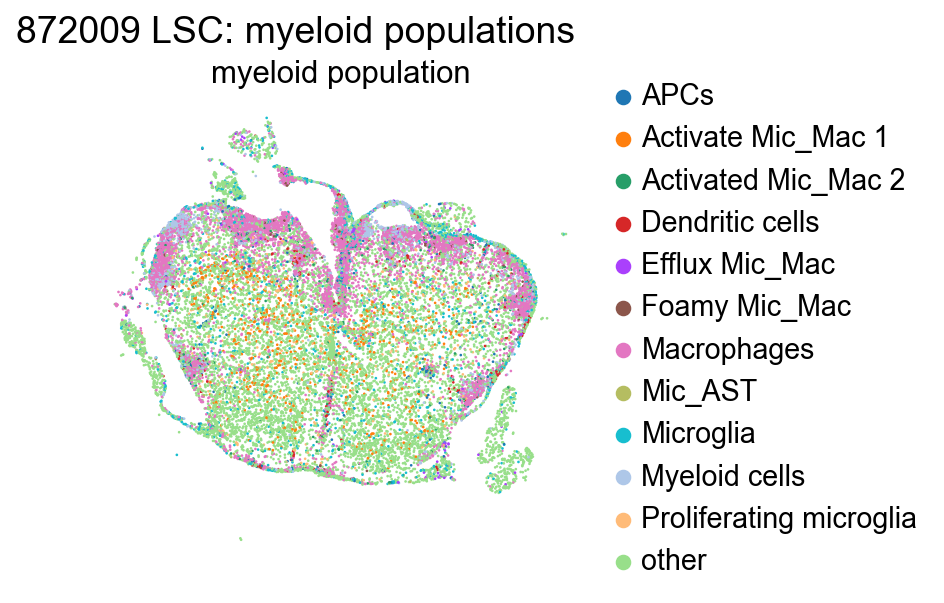

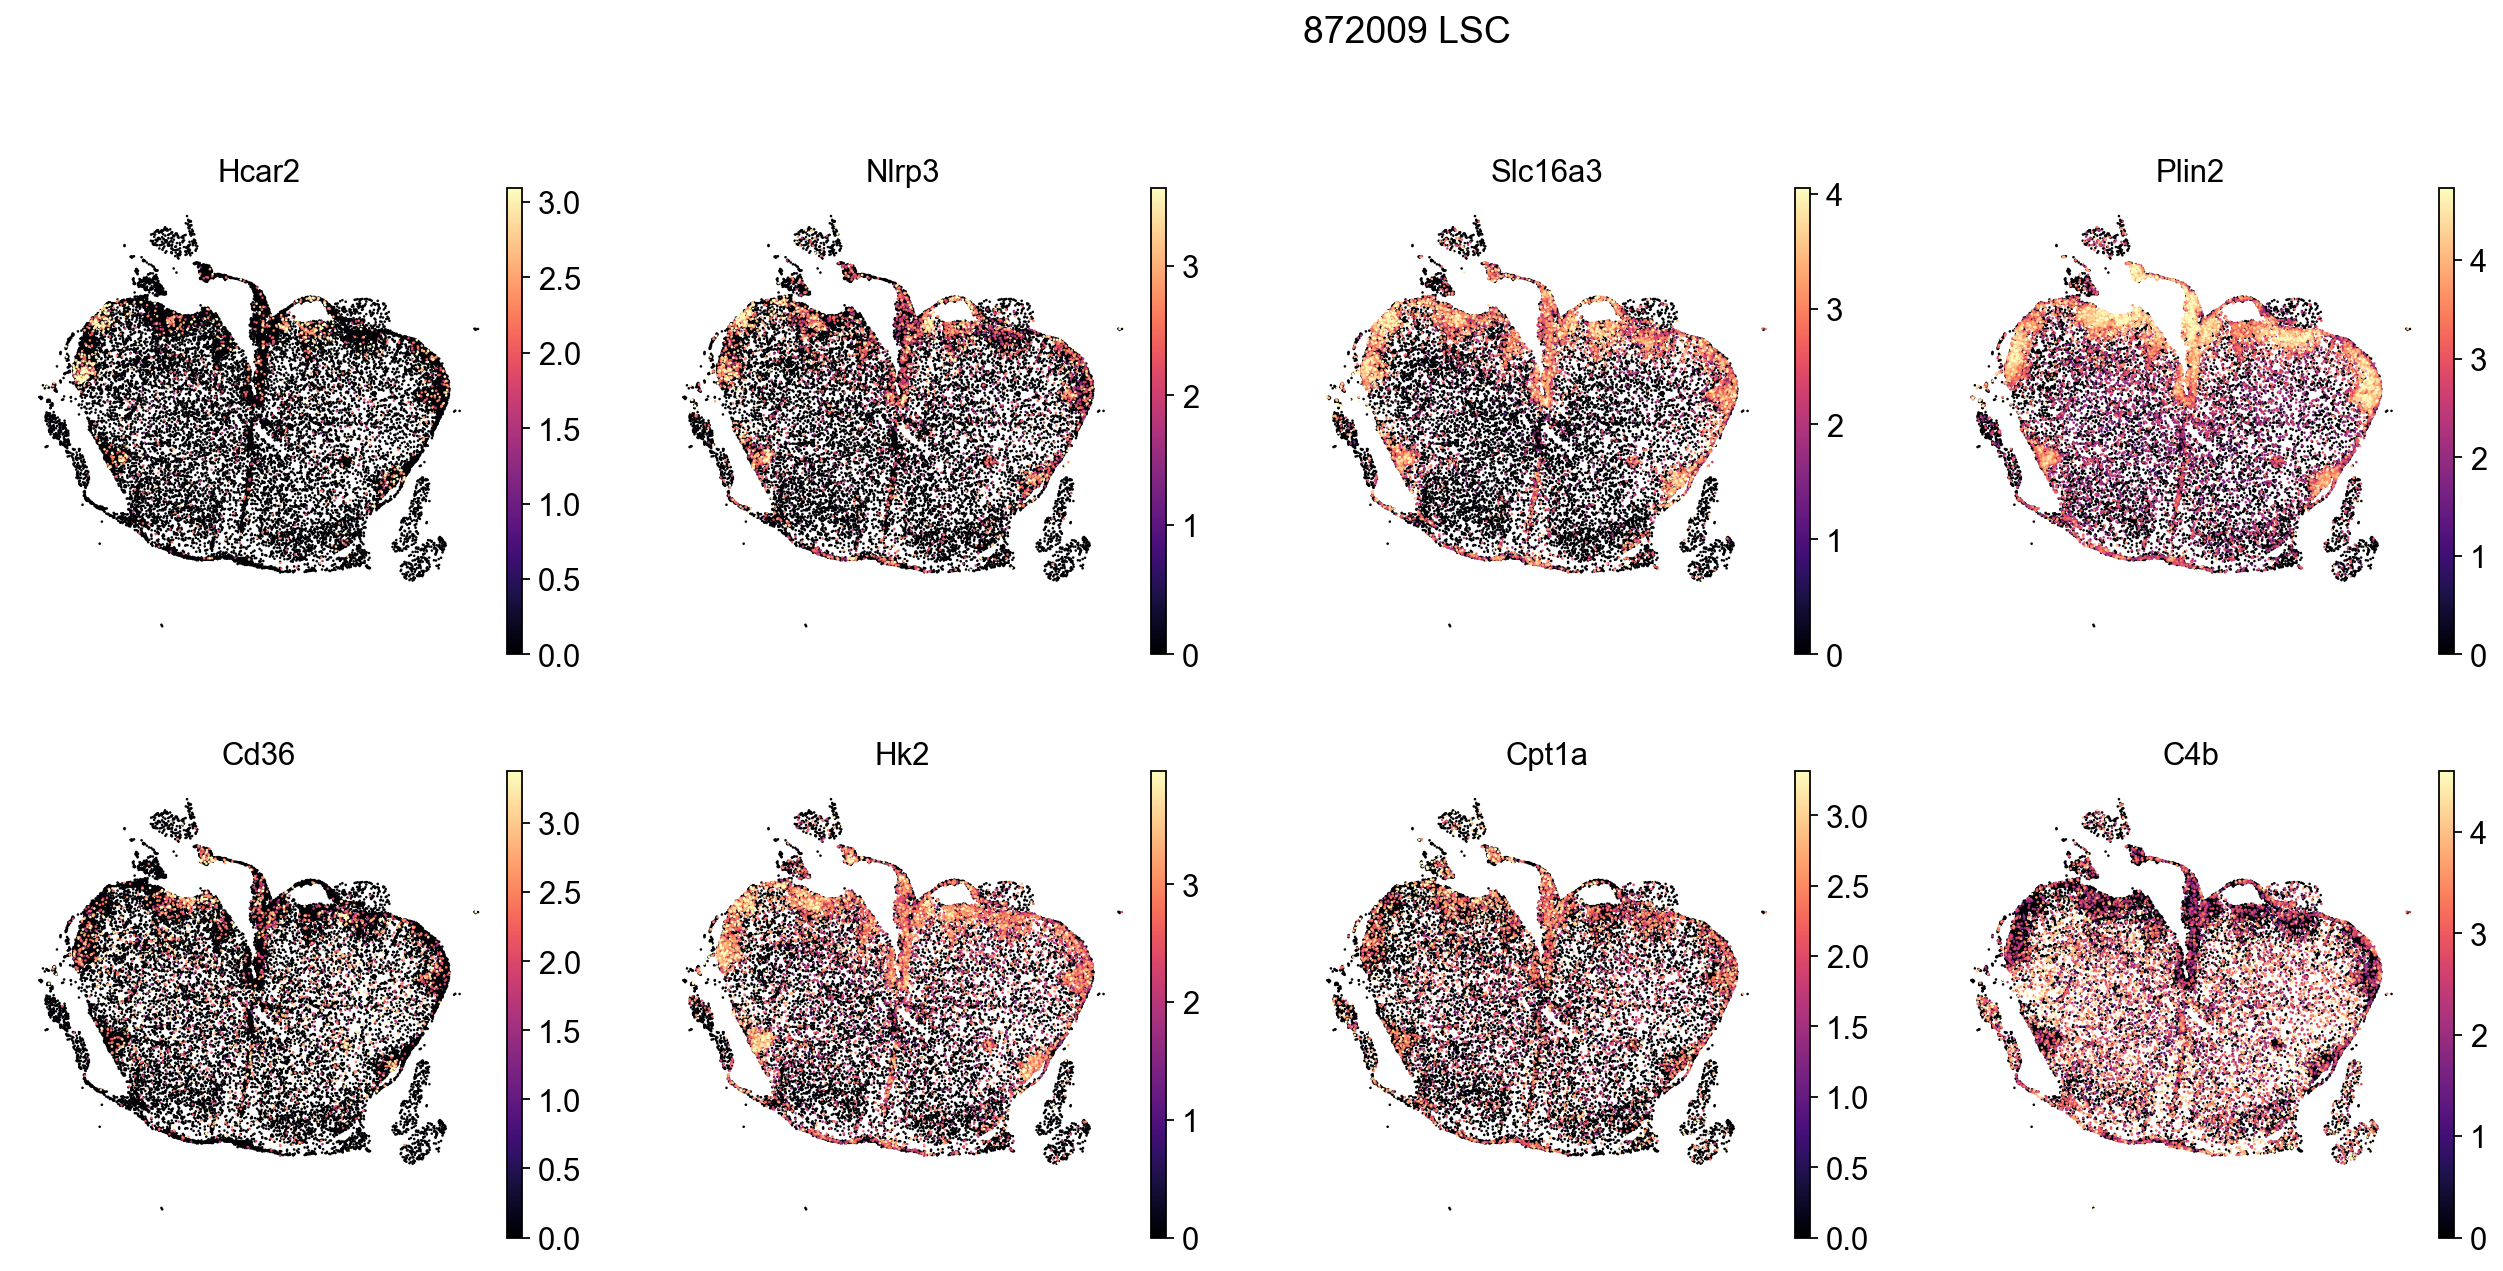

207346

In [11]:
peak = meta[(meta.condition == "EAE") & meta.course.astype(str).str.contains("peak", case=False)].sort_values("n_cells", ascending=False).index[0]
sub = ad[ad.obs["sample_name"].astype(str) == str(peak)].copy()
sub.obs["myeloid population"] = np.where(sub.obs["cell_type"].isin(MYELOID), sub.obs["cell_type"], "other")
sc.pl.spatial(sub, color=["myeloid population"], spot_size=20, show=False); plt.suptitle(f"{peak}: myeloid populations", y=1.02); plt.show()
genes = [g for g in ["Hcar2", "Nlrp3", "Slc16a3", "Plin2", "Cd36", "Hk2", "Cpt1a", "C4b"] if g in sub.var_names]
sc.pl.spatial(sub, color=genes, spot_size=20, cmap="magma", vmax="p99", ncols=4, show=False); plt.suptitle(f"{peak}", y=1.02); plt.show()
del sub, my, ad; gc.collect()

### Interpretation

**Composition.** Control myeloid tissue is 60 % homeostatic microglia and 26 % "Activate Mic_Mac 1"; the other nine populations are EAE-specific. Over the disease course the compartment is re-populated in a fixed order: at onset infiltrating myeloid cells (12–15 %), macrophages (8–15 %) and proliferating microglia (8–11 %) arrive; peak I is macrophage-dominated (31 %), peak II efflux-dominated (25 %), peak III the foamy stage (15 % foamy, 11 % macrophages); remission and chronic disease are dominated by "Activated Mic_Mac 2" (11–30 %) with a partial return of homeostatic microglia (41–50 %). Spatially, macrophages make up 29 % of myeloid cells within 10 µm of a lesion and 8 % beyond 500 µm; efflux cells, dendritic cells and infiltrating myeloid cells also concentrate at the core, while "Activate Mic_Mac 1" is absent from lesions (0 % near, 17 % far) and behaves like a grey-matter homeostatic state. Across samples the foamy (ρ 0.58), dendritic (0.69), APC (0.60) and macrophage (0.45) fractions rise with lesion burden and the homeostatic fractions fall (microglia −0.39, Activate Mic_Mac 1 −0.32).

**Metabolic identity.** Each population has its own metabolic signature. *Macrophages* are the hypoxic-glycolytic, lactate-exporting cells (highest glycolysis score 0.72 and lactate score 0.39; *Ldha*, *Hif1a*, *Eno1*, *Pgk1*, *Tpi1*, *Slc16a3*, *Acsl1*), and become more so toward the lesion core (*Ldha* 1.7 → 2.3, *Plin2* 1.8 → 2.5). *Foamy Mic_Mac* are the only population that oxidises fatty acids (fatty-acid-supply score 0.24 versus ≤ 0.08 elsewhere; *Cpt1a* 45 %, *Acaa2*, *Slc25a20*) on top of the highest lipid-storage score (0.72; *Plin2* 3.5, *Pparg*, *Nr1h3*, *Idh1*, *G6pdx*) and the lowest cholesterol synthesis (−0.60): PPARγ-driven lipid-burning foam cells, already saturated at every lesion distance. *Activated Mic_Mac 2* is the lipid-handling, LXR-type state (*Lpl* +1.6 log2 vs homeostatic microglia, *Abca1*, *Acaca*, *Mlxipl*, *Nfe2l2*, *Pdk1*; lipid storage +0.18, lactate +0.25) that persists into remission and chronic disease. *Infiltrating myeloid cells* are glycolytic (*Slc2a1*, *Slc2a3*, *Pfkp*, *Slc16a3*) and carry the sensors (*Hcar2* 20 %, *Nlrp3* 45 %, *Ffar2* 11 %). *Proliferating microglia* combine *Cd36* (+1.1 log2), *Hcar2* (21 %), *Cpt1c*, *Cpt2*, *Acly* and *Ppargc1a*. *APCs* are the one population with active cholesterol synthesis (*Srebf2*, *Hmgcr*, *Lss*; score +0.45 vs microglia). *Homeostatic microglia* keep *Ppara*, *Ffar3*, *Txnip*, *Apod*, *Mlxipl*. "Activate Mic_Mac 1" scores oxidative (*Ppargc1a*, *Mfn2*, *Sirt3*, *Mpc2*, TCA +0.26) but its top genes (*Eno2*, *Aldoc*) are neuronal / astrocytic, so it is most likely homeostatic microglia in grey matter with neuropil in the segment. "Efflux Mic_Mac" has every gene 1–4 log2 below homeostatic microglia (*Hcar2* −4.1) and is a low-transcript state rather than a metabolic one; "Mic_AST" carries astrocyte genes (*Slc16a1*, *Fabp7*, *Plin4*, *Bdh1*) and is a doublet-like cluster.

**Ketone handling.** *Bdh1* is a minor myeloid gene (≤ 7 % in most populations; 21 % in Activate Mic_Mac 1 and 19 % in Mic_AST, both admixed with other cells; 11 % in proliferating microglia) and falls in every population toward lesions and with lesion burden (microglia ρ −0.30); *Ppara* is ≤ 2 % everywhere and lower in every EAE-specific population than in homeostatic microglia (foamy −2.2, activated 2 −1.2, macrophages −1.1 log2). Myeloid cells therefore do not make ketone bodies. What they have is the *transport* and *sensing* arm: MCT4 (*Slc16a3*) in 61 % of macrophages, 57 % of infiltrating myeloid cells, 54 % of foamy cells and 48 % of Activated Mic_Mac 2, rising toward the lesion core in microglia (0.58 → 0.79) and macrophages (1.64 → 1.93); *Hcar2* in 21 % of proliferating microglia, 20 % of infiltrating myeloid cells, 13 % of Activated Mic_Mac 2, 8 % of homeostatic microglia, 5 % of macrophages and 2 % of foamy cells; *Nlrp3* in 45 % of infiltrating myeloid cells, 28 % of macrophages, 22–26 % of microglia and proliferating microglia, 14 % of foamy cells; *Ffar2* in 11–13 % of infiltrating myeloid cells and APCs. *Hcar2* and *Nlrp3* co-occur 1.5–1.9× more often than expected in every population.

**The *Hcar2*⁺ phenotype is the same in every population.** *Hcar2*⁺ cells are 2–2.7× enriched for *Cd36*, *Tnf* and *Ccl2*, 1.6–2× for *Cst7* and *Mlxipl*, and, in microglia and proliferating microglia, 1.5–1.9× for the homeostatic markers *P2ry12* and *Tmem119* together with *Ldhb* and *Aldoc*; they are depleted of *Gpnmb* (0.39 in microglia), *Igf1* (0.48), *Nr1h3* and, in every population, of the recruitment marker *Ccr2*. The BHB-responsive myeloid cell is thus a *Cd36*⁺ *Tnf*⁺ *Ccl2*⁺ microglia-like cell that has kept its homeostatic identity and is *not* the *Gpnmb*⁺ *Igf1*⁺ lipid-laden phagocyte of the lesion core. Consistently, within homeostatic microglia *Hcar2* falls from 0.26 beyond 500 µm to 0.06 within 10 µm of a lesion while *Plin2* (0.74 → 1.46), *Slc16a3* and *Cpt1a* rise and *Cd36* and *Hk2* fall: microglia entering the lesion trade the *Hcar2*⁺ *Cd36*⁺ inflammatory phenotype for a lipid-storing, lactate-exporting, fatty-acid-oxidising one. Only infiltrating myeloid cells (0.40 → 0.76) and macrophages (0.08 → 0.17) carry *Hcar2* into the core. Over the course, microglial *Hcar2* is an onset / first-peak signal (0.27–0.47 at onset and peak I, 0.10–0.17 at later peaks and in remission, 0.05 in controls); MCT4 follows the same time course; *Plin2* and *Cpt1a* in microglia rise monotonically to peak III (0.3 → 1.4 and 0.2 → 0.6) and stay elevated in remission and chronic disease, tracking lesion burden across samples (ρ 0.61 and 0.60).

**Who surrounds the disease-associated oligodendrocyte.** Within 30 µm of DA versus homeostatic oligodendrocytes of the same sample, every EAE-specific myeloid population is enriched, in the order efflux (3.3; lesion-matched 2.6), foamy (3.1; 1.8), Activated Mic_Mac 2 (2.8; 1.8), macrophages (2.8; 1.7), dendritic cells (2.4; 1.5), APCs and infiltrating myeloid cells (1.9; 1.2–1.5), homeostatic microglia (1.6; 1.4) and proliferating microglia (1.5; 1.3), while "Activate Mic_Mac 1" is depleted (0.38; 0.46). Around *C4b*-high versus *C4b*-negative oligodendrocytes the picture sharpens: Activated Mic_Mac 2 (3.3; matched 2.8), APCs (2.4; 2.2), homeostatic microglia (2.0; 1.8), proliferating microglia and macrophages (1.7; 1.3–1.4) are enriched, but foamy (0.85) and efflux (0.97; matched 0.57) cells are not. The *C4b*⁺ oligodendrocyte therefore sits with activated and homeostatic microglia (the *Hcar2*⁺ *Nlrp3*⁺ *Lpl*⁺ Activated Mic_Mac 2 state above all), not with the foam cells of the lesion core; the *Hcar2*⁺ subsets of each population are enriched to the same degree as the population as a whole, so *Hcar2* marks a state of these neighbours rather than selecting them.

**Bottom line.** The EAE myeloid compartment divides metabolically into glycolytic lactate-exporting macrophages and infiltrating cells at the core, PPARγ-driven fatty-acid-burning foam cells, an LXR-type lipid-handling activated-microglia state that persists into remission and surrounds *C4b*⁺ oligodendrocytes, and homeostatic microglia that carry the BHB receptor. None of them make ketone bodies; the BHB-responsive cell is the *Hcar2*⁺ *Cd36*⁺ *Tnf*⁺ *Ccl2*⁺ microglia-like cell of early disease, which loses *Hcar2* as it becomes a lipid-storing lesion phagocyte. For a BHB / *Hcar2*-directed intervention the window is onset to first peak and the target is the activated-microglia niche around DA oligodendrocytes, not the foam-cell core.

**Caveats.** Control tissue has too few cells of the EAE-specific populations for EAE-vs-control tests per population, so comparisons are paired against homeostatic microglia within EAE samples. "Activate Mic_Mac 1" and "Mic_AST" carry non-myeloid genes and are probably admixed; "Efflux Mic_Mac" is a low-transcript state. *Hcar2*, *Ffar2*, *Ppara* and *Bdh1* sit near the detection floor in several populations; in situ, genes detected in a segment can come from neighbours; the panel has no *Oxct1* / *Hmgcs2*, so ketone utilisation itself is not measured.